In [2]:
savepathIMG = "../Images/"
from BCI_Library import plot_violin_all_subj, plot_violin_track_single_fold
Interesting_regions_right =   [5, 33, 45, 49]
Interesting_regions_left = [4, 32, 44, 48,]

# Before 12/2025, selection MyCriteria on band 4 - 30 Hz

## Personalized freqs vs Standard freqs

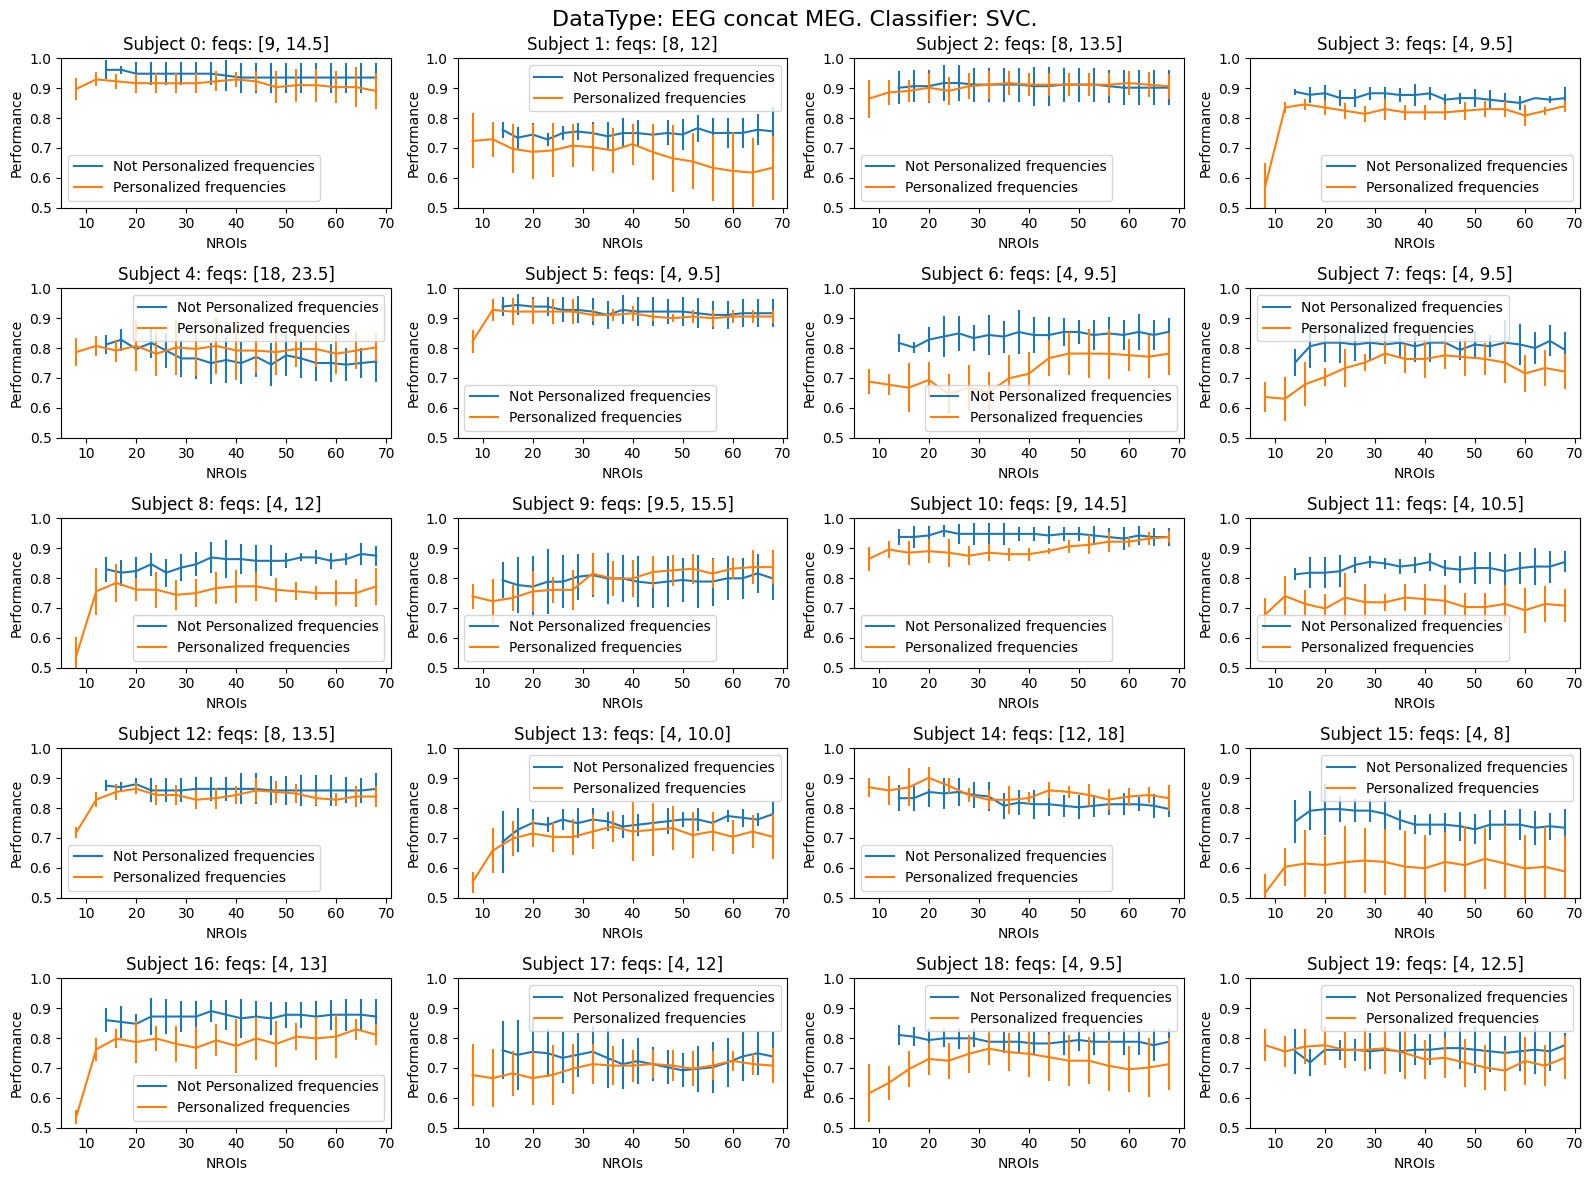

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"DataType":"EEG concat MEG", "Classifier":"SVC"}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Personalized_Freq_Range":False})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="Not Personalized frequencies")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Personalized_Freq_Range":True})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="Personalized frequencies")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')




    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}: feqs: {freq_personalized[f'subject_{subject}']}")
    ax.set_xlabel("NROIs")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
#plt.savefig(savepathIMG+"freq_personalized_vs_not_SVM.png")
plt.show()

## Different Classifiers - Fixed Datatypes

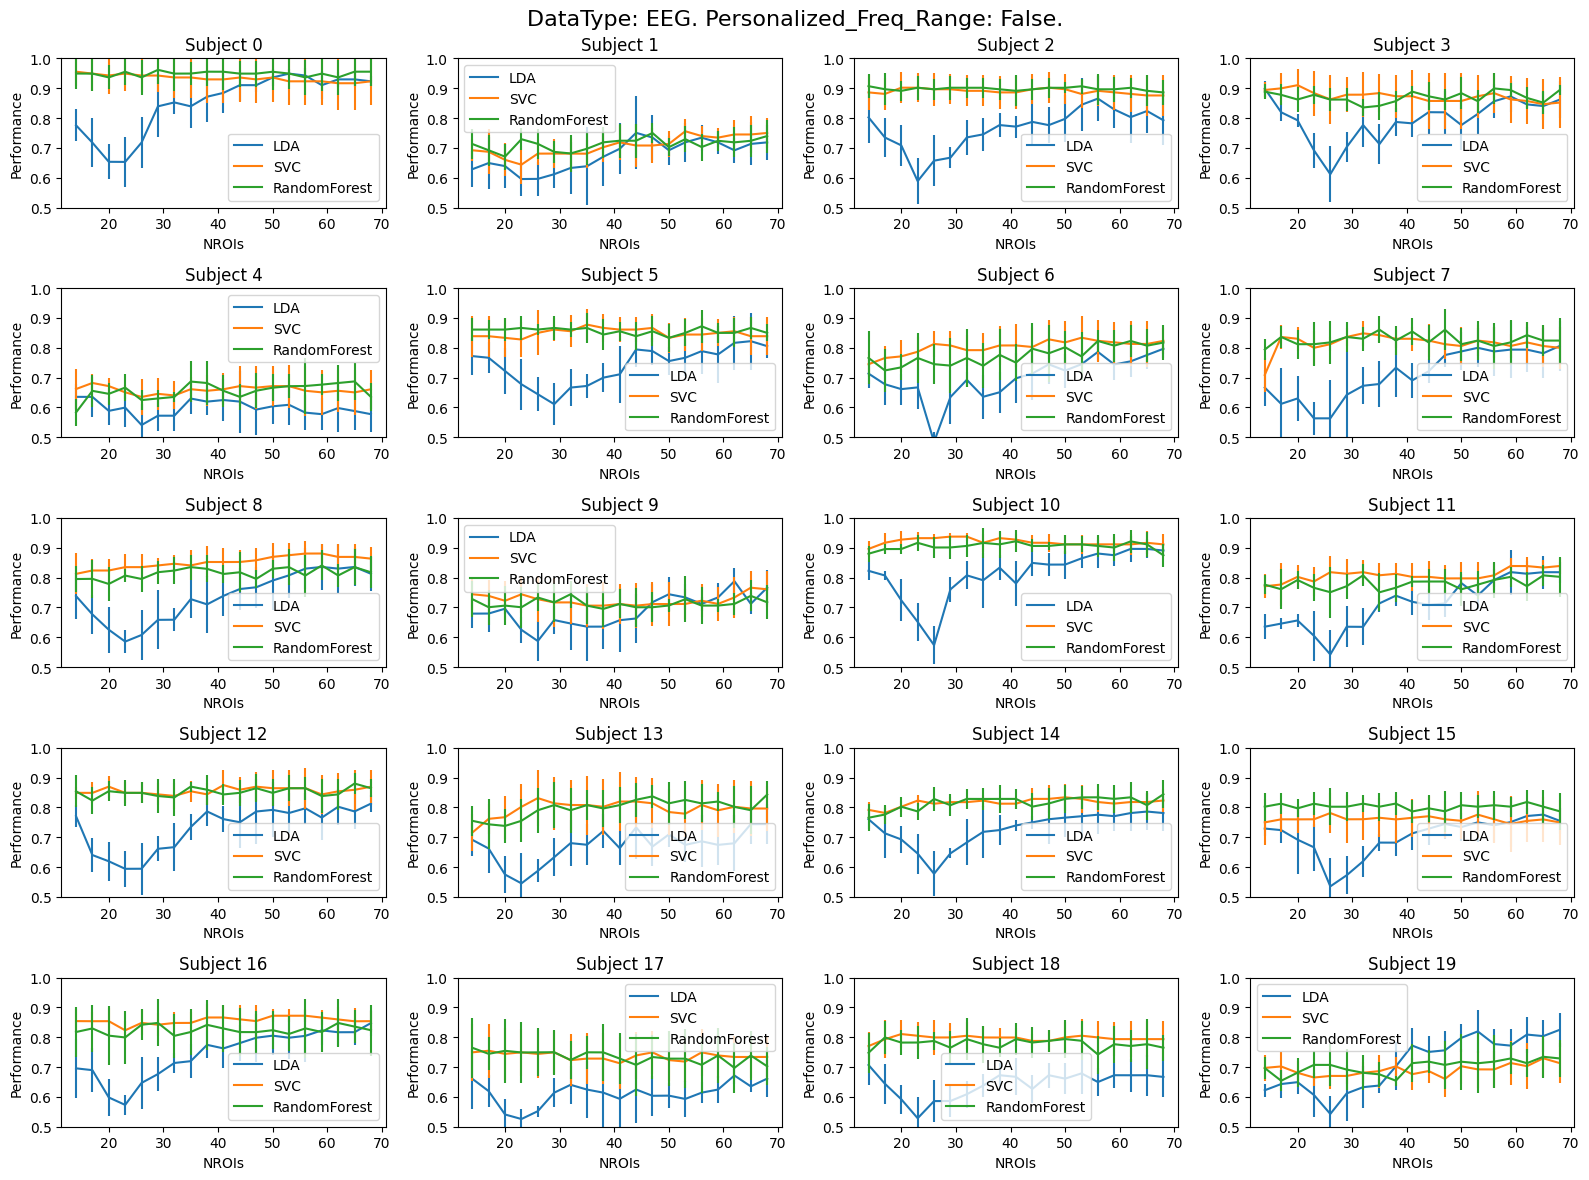

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"DataType":"EEG","Personalized_Freq_Range":False}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Classifier":"LDA"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="LDA")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Classifier":"SVC"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="SVC")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')

    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Classifier":"RandomForest"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="RandomForest")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C2')




    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}")
    ax.set_xlabel("NROIs")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
#plt.savefig(savepathIMG+"EEG_notPersonalised_vs_Classifier.png")
plt.show()

## Different Datatypes - Fixed Classifiers

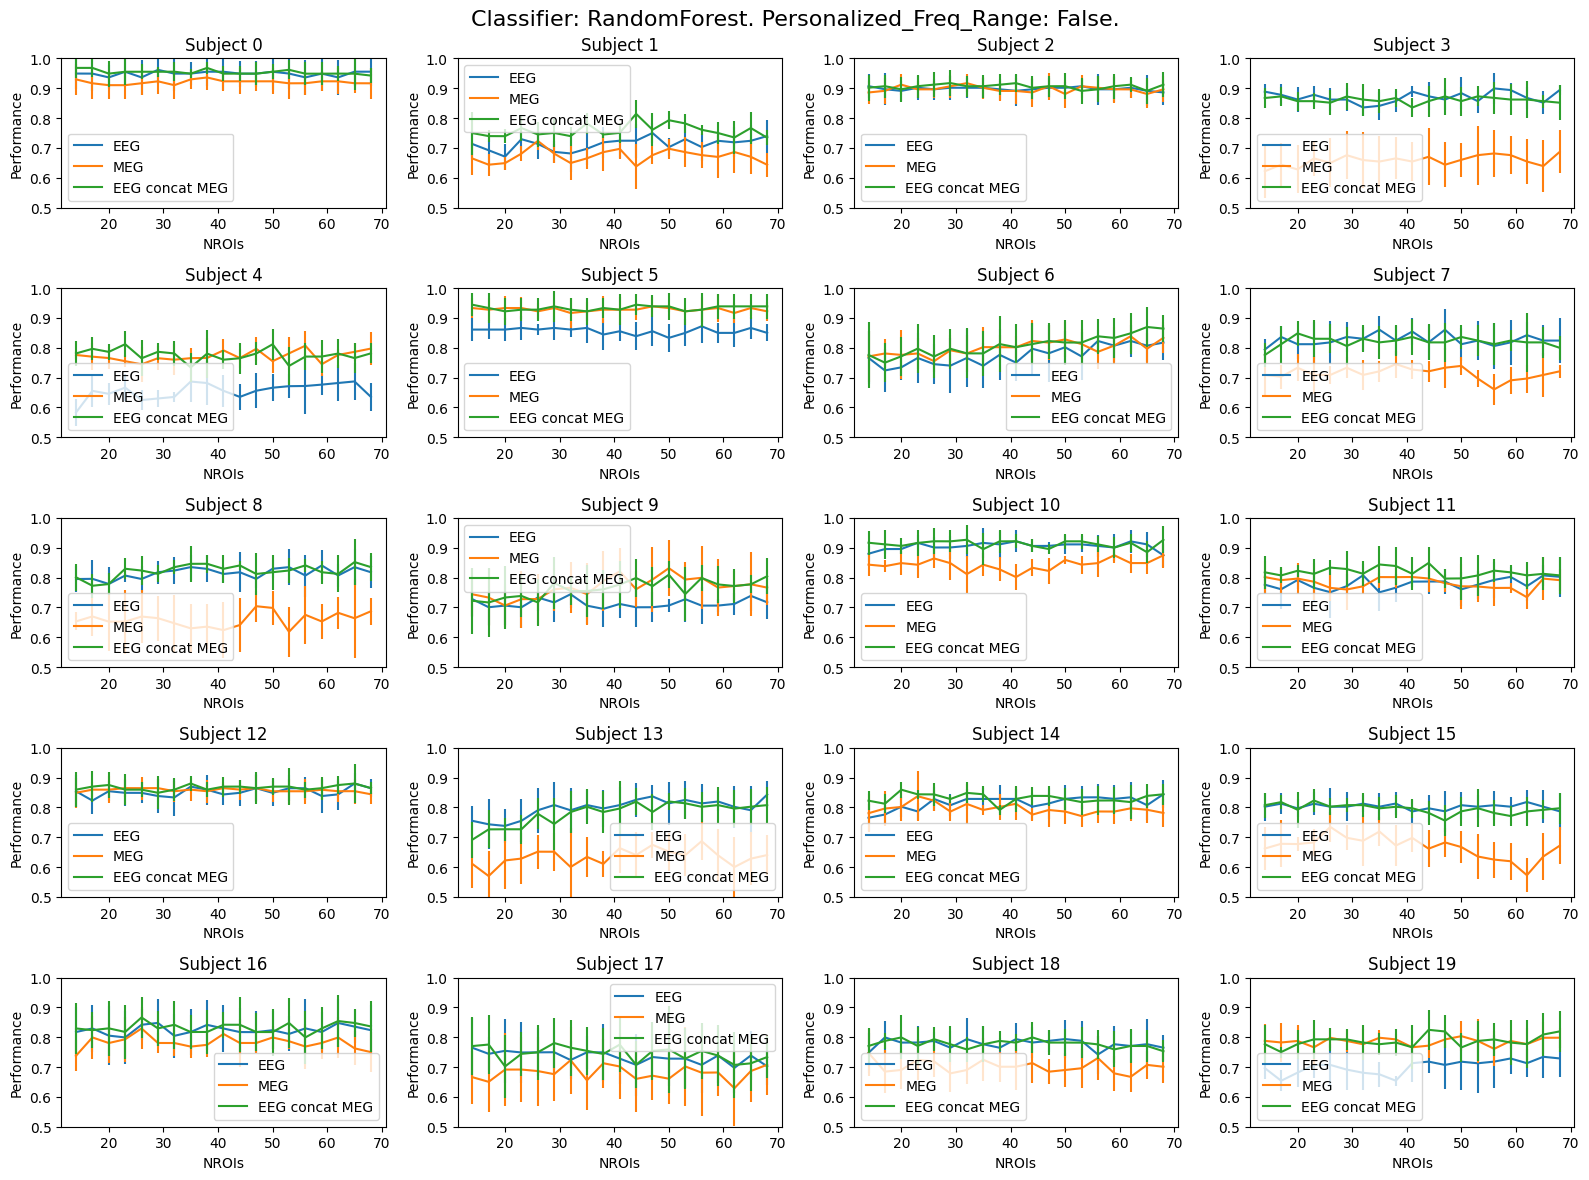

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"Classifier":"RandomForest","Personalized_Freq_Range":False,}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "DataType":"EEG", "Comments":"-"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="EEG")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "DataType":"MEG", "Comments":"-"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="MEG")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')

    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "DataType":"EEG concat MEG", "Comments":"ROIs: EEG then MEG"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="EEG concat MEG")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C2')




    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}")
    ax.set_xlabel("NROIs")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
#plt.savefig(savepathIMG+"EEG_concat_MEG_vs_EEG_vs_MEG_SVM.png")
plt.show()

In [3]:
rows

,ROIs,NROIs,DataType,freqs_band,subject,Classifier,Performance,Features,Comments,Date,Personalized_Freq_Range
2641,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",14.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.7894736842105263, 0.8157894736842105, 0.684...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2642,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",17.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.7368421052631579, 0.7368421052631579, 0.736...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2643,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",20.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.7631578947368421, 0.7894736842105263, 0.736...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2644,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",23.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.868421052631579, 0.7368421052631579, 0.7105...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2645,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",26.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.7631578947368421, 0.7894736842105263, 0.763...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2646,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",29.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.7894736842105263, 0.8157894736842105, 0.736...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2647,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",32.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.8421052631578947, 0.7368421052631579, 0.736...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2648,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",35.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.8157894736842105, 0.7894736842105263, 0.736...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2649,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",38.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.7894736842105263, 0.8157894736842105, 0.710...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False
2650,"[[4, 5, 32, 33, 44, 45, 48, 49, 14, 59, 63, 51...",41.0,EEG concat MEG,"((4, 8), (8, 13), (13, 25))",19.0,RandomForest,"[0.7631578947368421, 0.7894736842105263, 0.710...",PowerSpectra - MeanMax band,ROIs: EEG then MEG,2025-11-25,False


## Only Mean - Only Max

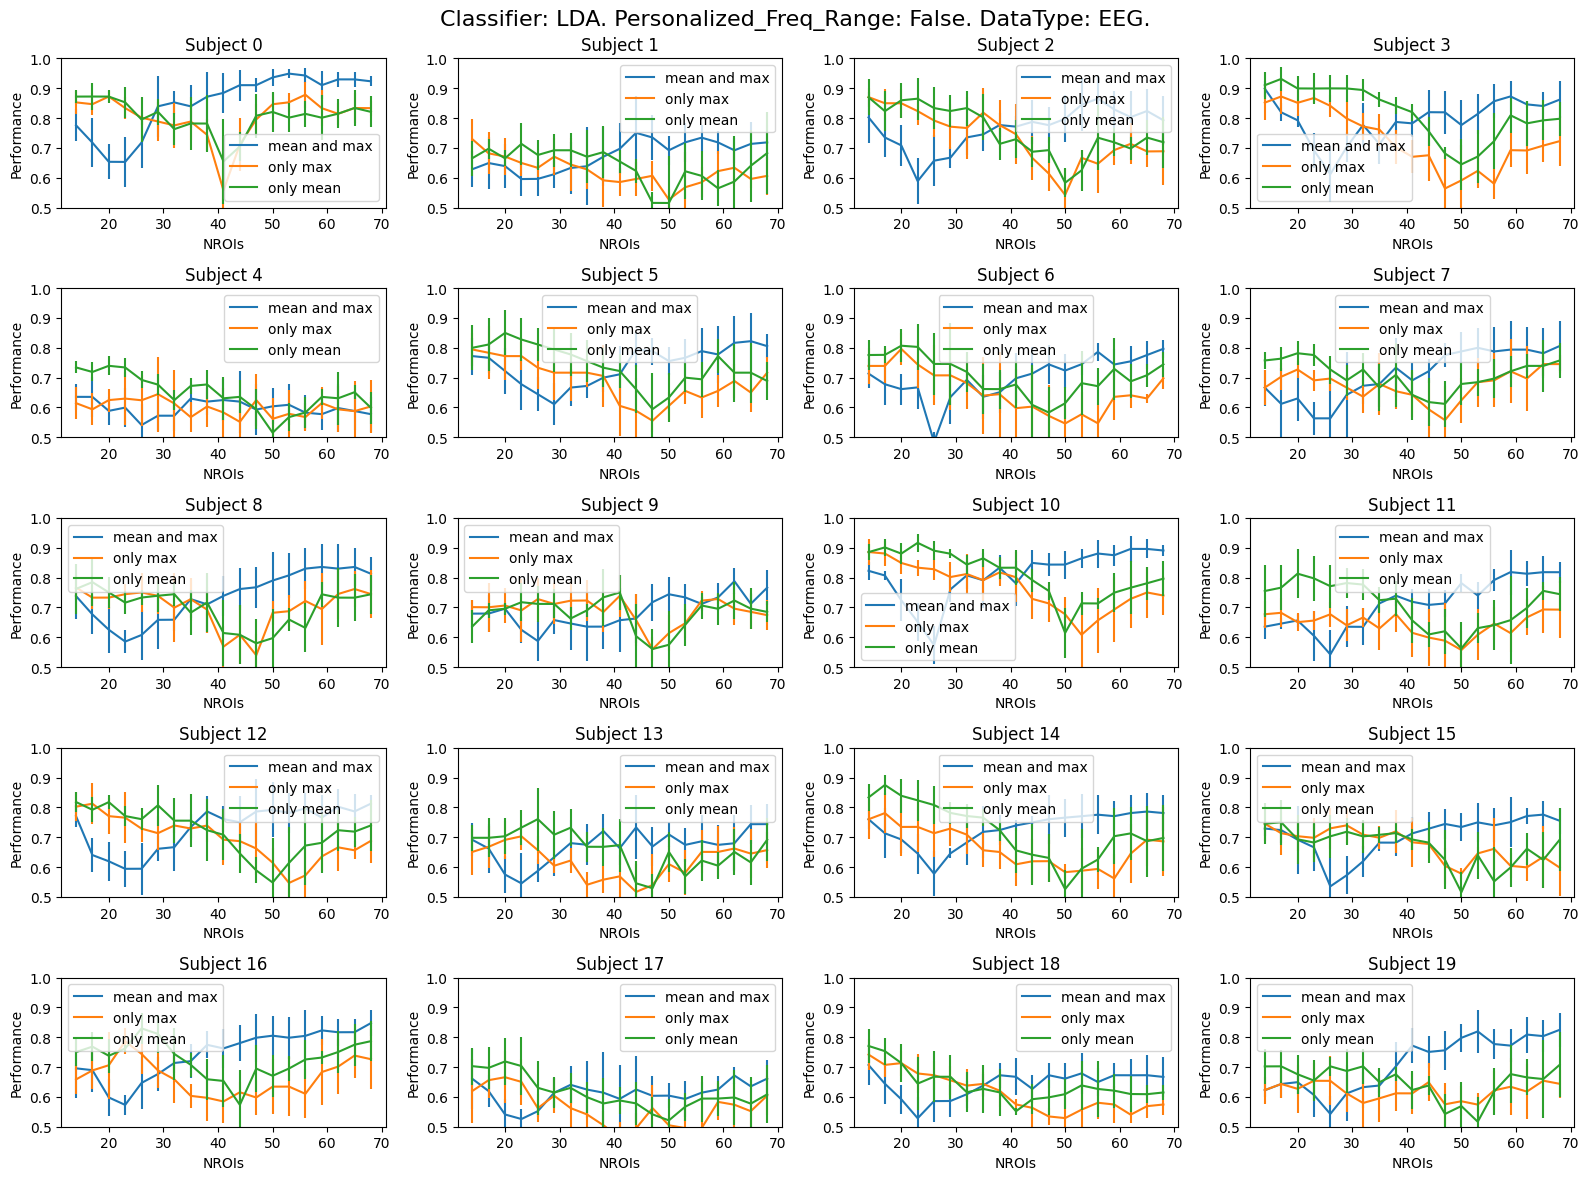

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances.pkl")
PerData2 = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_ony1Feature.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"Classifier":"LDA","Personalized_Freq_Range":False,"DataType":"EEG"}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values 
    ax.plot(nrois, allperf.mean(axis=1),label="mean and max")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    
    rows = select_rows(PerData2, dict_fixed_selection | {"subject":subject, "Comments":"Only max"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="only max")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')

    rows = select_rows(PerData2, dict_fixed_selection | {"subject":subject, "Comments":"Only mean"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="only mean")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C2')




    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}")
    ax.set_xlabel("NROIs")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
savepathIMG = "../Images/"
plt.savefig(savepathIMG+"Perf_max_mean_EEF_LDA.png")
plt.show()

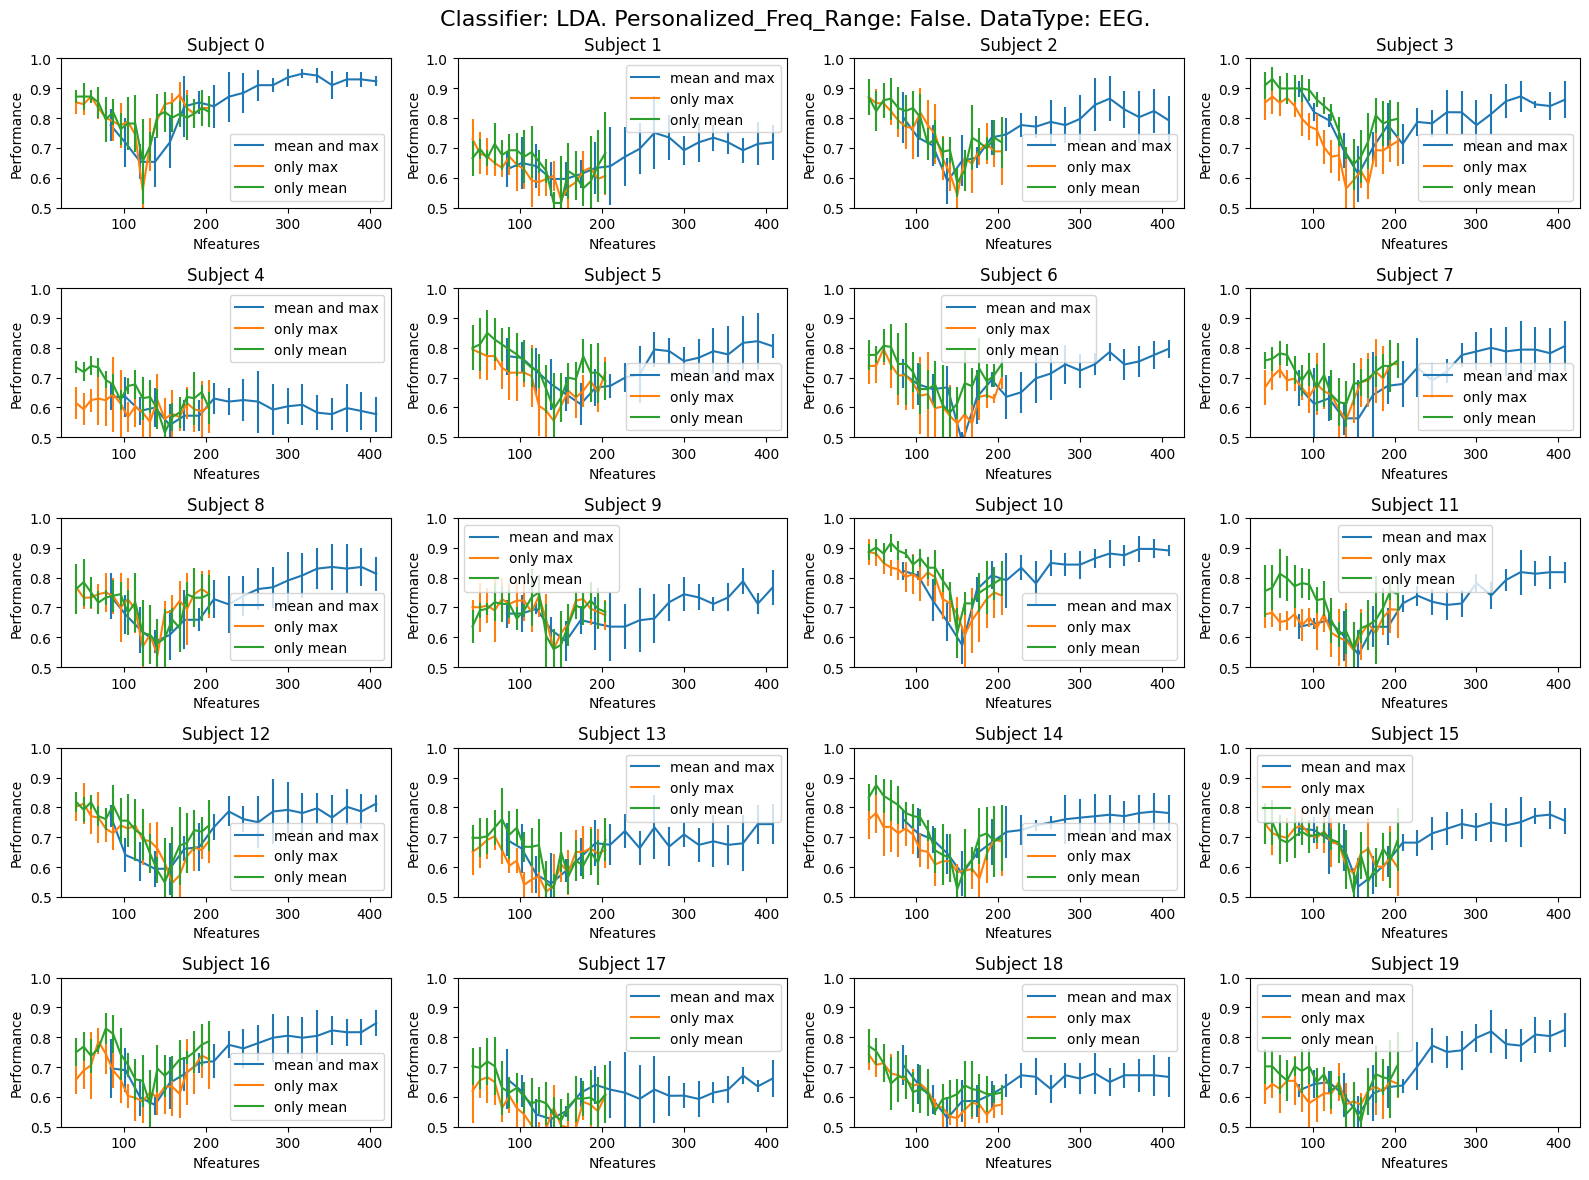

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances.pkl")
PerData2 = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_ony1Feature.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"Classifier":"LDA","Personalized_Freq_Range":False,"DataType":"EEG"}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values * 6
    ax.plot(nrois, allperf.mean(axis=1),label="mean and max")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    
    rows = select_rows(PerData2, dict_fixed_selection | {"subject":subject, "Comments":"Only max"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values * 3
    ax.plot(nrois, allperf.mean(axis=1),label="only max")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')

    rows = select_rows(PerData2, dict_fixed_selection | {"subject":subject, "Comments":"Only mean"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values * 3
    ax.plot(nrois, allperf.mean(axis=1),label="only mean")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C2')




    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}")
    ax.set_xlabel("Nfeatures")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
savepathIMG = "../Images/"
plt.savefig(savepathIMG+"Perf_max_mean_EEF_LDA_xaxis_Nfeatures.png")
plt.show()

## Regions' Investigation

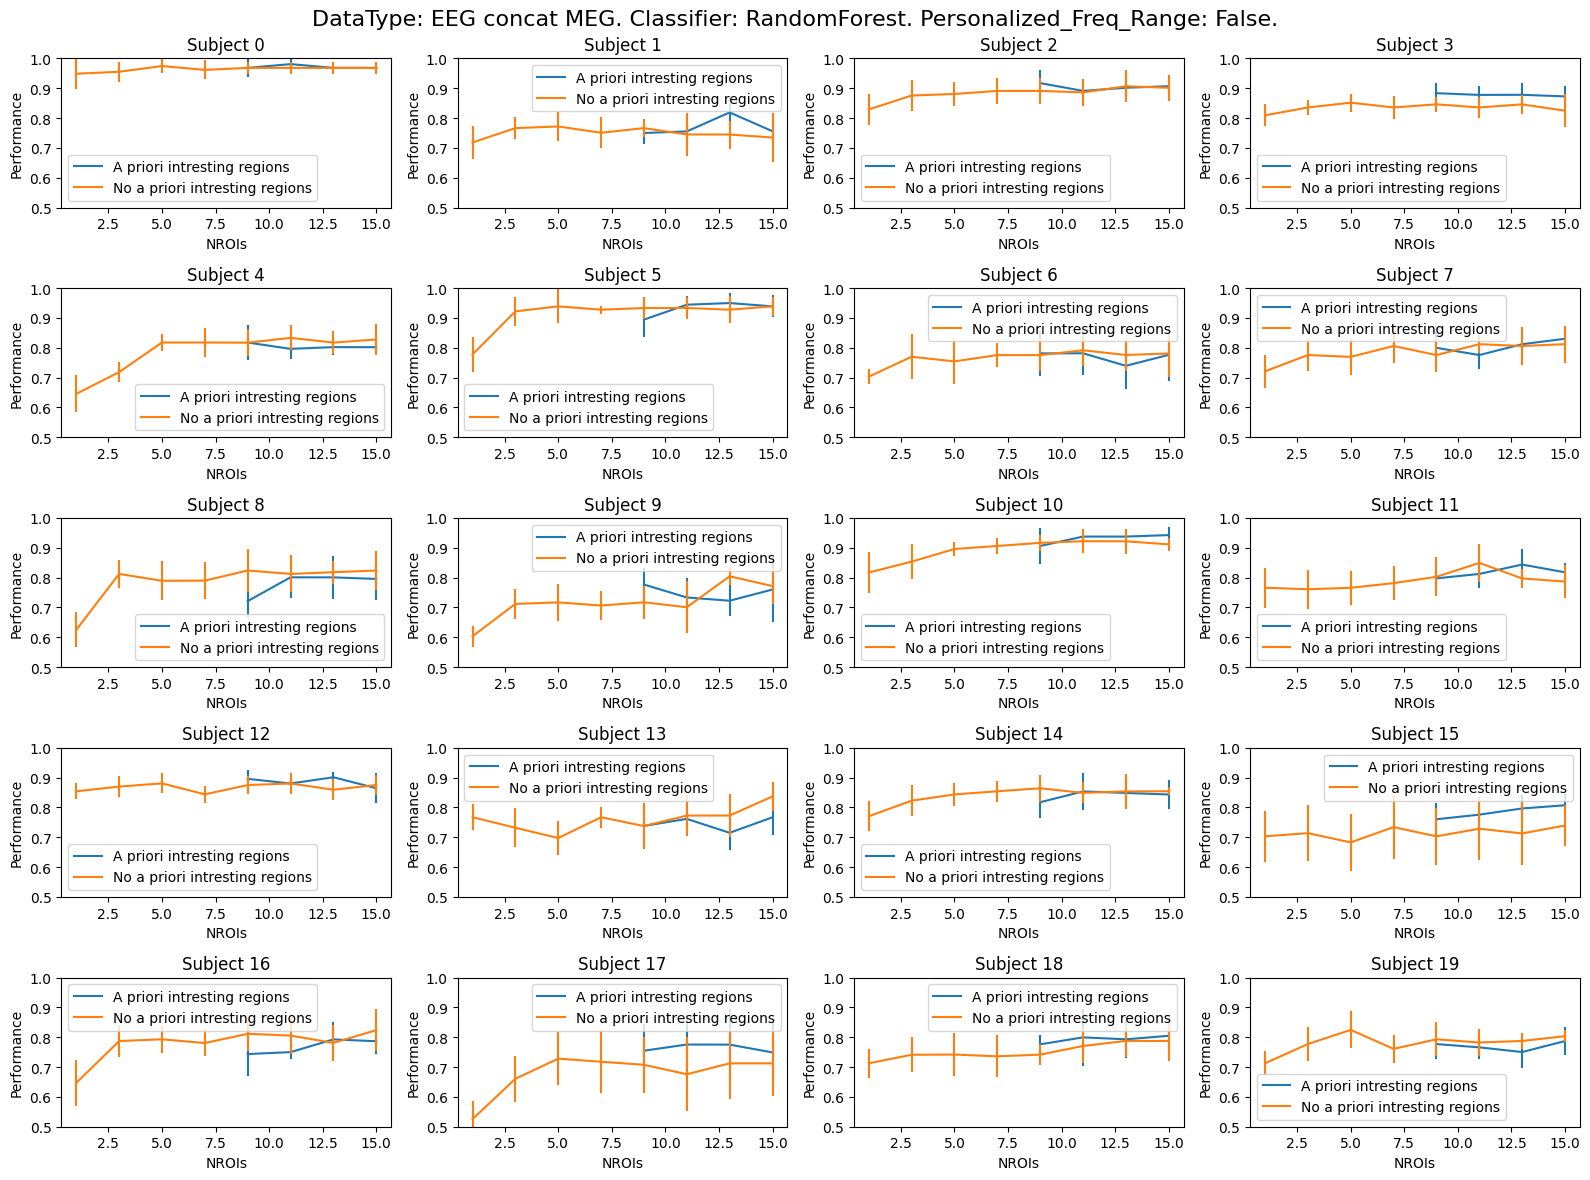

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_Important_regions_all.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"DataType":"EEG concat MEG", "Classifier":"RandomForest", "Personalized_Freq_Range":False}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Comments":"Yes Important Regions"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="A priori intresting regions")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject,  "Comments":"No Interesting Regions"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="No a priori intresting regions")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')

    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}")
    ax.set_xlabel("NROIs")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
#plt.savefig(savepathIMG+"freq_personalized_vs_not_SVM.png")
plt.show()

## Single graph with every subject vs Classifier-DataType

### regions old method - Interesting + selected

In [ ]:
pd.read_pickle("../Results/BCI_Performances/BCI_Performances.pkl")

,ROIs,NROIs,DataType,freqs_band,subject,Classifier,Performance,Features,Comments,Date,Personalized_Freq_Range
0,"[4, 5, 32, 33, 44, 45, 48, 49, 23, 15, 14, 22,...",14.0,EEG,"((4, 8), (8, 13), (13, 25))",0.0,LDA,"[0.78125, 0.6774193548387096, 0.83870967741935...",PowerSpectra - MeanMax band,-,2025-11-20,False
1,"[4, 5, 32, 33, 44, 45, 48, 49, 23, 15, 14, 22,...",17.0,EEG,"((4, 8), (8, 13), (13, 25))",0.0,LDA,"[0.8125, 0.6774193548387096, 0.580645161290322...",PowerSpectra - MeanMax band,-,2025-11-20,False
2,"[4, 5, 32, 33, 44, 45, 48, 49, 23, 15, 14, 22,...",20.0,EEG,"((4, 8), (8, 13), (13, 25))",0.0,LDA,"[0.75, 0.5806451612903226, 0.6129032258064516,...",PowerSpectra - MeanMax band,-,2025-11-20,False
3,"[4, 5, 32, 33, 44, 45, 48, 49, 23, 15, 14, 22,...",23.0,EEG,"((4, 8), (8, 13), (13, 25))",0.0,LDA,"[0.8125, 0.6451612903225806, 0.612903225806451...",PowerSpectra - MeanMax band,-,2025-11-20,False
4,"[4, 5, 32, 33, 44, 45, 48, 49, 23, 15, 14, 22,...",26.0,EEG,"((4, 8), (8, 13), (13, 25))",0.0,LDA,"[0.75, 0.6774193548387096, 0.8387096774193549,...",PowerSpectra - MeanMax band,-,2025-11-20,False
...,...,...,...,...,...,...,...,...,...,...,...
4695,"[[14, 44, 59, 45, 58, 63, 32, 51, 21, 20, 22, ...",52.0,EEG concat MEG,"((4, 8), (8, 12), (12, 30))",19.0,RandomForest,"[0.8157894736842105, 0.7631578947368421, 0.684...",PowerSpectra - MeanMax band,No Interesting Regions,2025-12-01,False
4696,"[[14, 44, 59, 45, 58, 63, 32, 51, 21, 20, 22, ...",56.0,EEG concat MEG,"((4, 8), (8, 12), (12, 30))",19.0,RandomForest,"[0.8421052631578947, 0.7894736842105263, 0.763...",PowerSpectra - MeanMax band,No Interesting Regions,2025-12-01,False
4697,"[[14, 44, 59, 45, 58, 63, 32, 51, 21, 20, 22, ...",60.0,EEG concat MEG,"((4, 8), (8, 12), (12, 30))",19.0,RandomForest,"[0.7894736842105263, 0.7105263157894737, 0.710...",PowerSpectra - MeanMax band,No Interesting Regions,2025-12-01,False
4698,"[[14, 44, 59, 45, 58, 63, 32, 51, 21, 20, 22, ...",64.0,EEG concat MEG,"((4, 8), (8, 12), (12, 30))",19.0,RandomForest,"[0.8947368421052632, 0.7105263157894737, 0.684...",PowerSpectra - MeanMax band,No Interesting Regions,2025-12-01,False


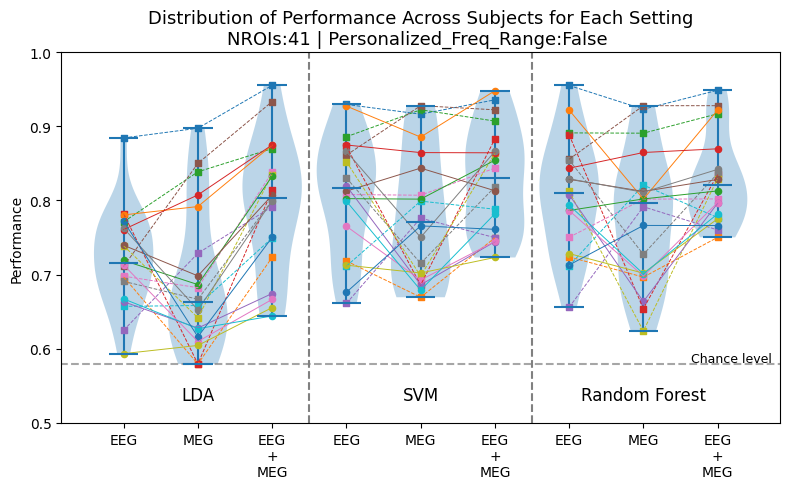

In [ ]:
import pandas as pd

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances.pkl")
VisualizigNROIs=41
dict_fixed_selection = {"NROIs":VisualizigNROIs,  "Personalized_Freq_Range":False}
classifiers=["LDA","LDA","LDA","SVC","SVC","SVC","RandomForest","RandomForest","RandomForest"]
Datatypes=["EEG","MEG","EEG concat MEG","EEG","MEG","EEG concat MEG","EEG","MEG","EEG concat MEG"]
dict_per_setting = {"DataType":Datatypes, "Classifier":classifiers}
x_ticklabels=[_.replace(" concat ","\n+\n") for _ in Datatypes]
divisioni = [0,3,6,9]
textes = ["LDA", "SVM", "Random Forest"]
textes_x_positions = [.19, .5, .81]
savepathIMG+"Performance_vs_Setting_41_ROIs.png"


plot_violin_all_subj(PerData,  9,  dict_fixed_selection,  dict_per_setting,
                  x_ticklabels,  textes,  textes_x_positions, divisioni,
                  track_subjects=True,  savepath=False)


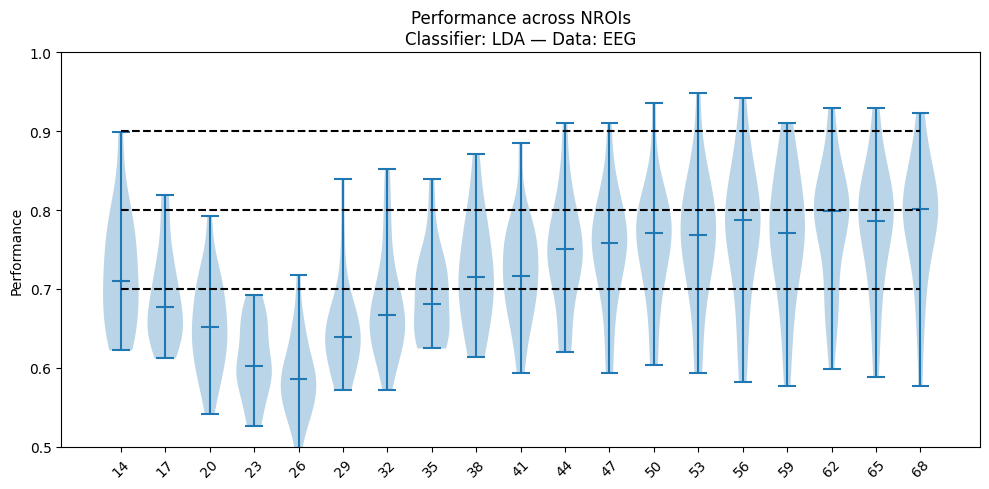

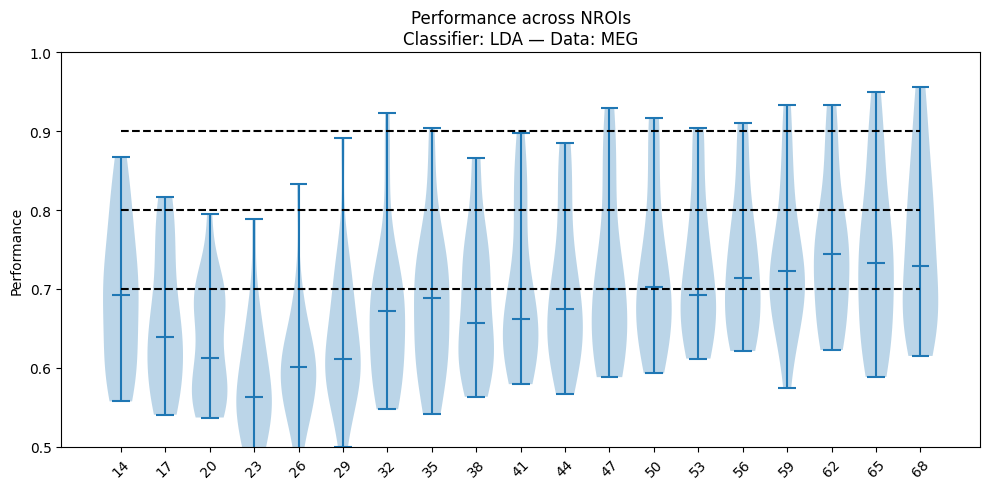

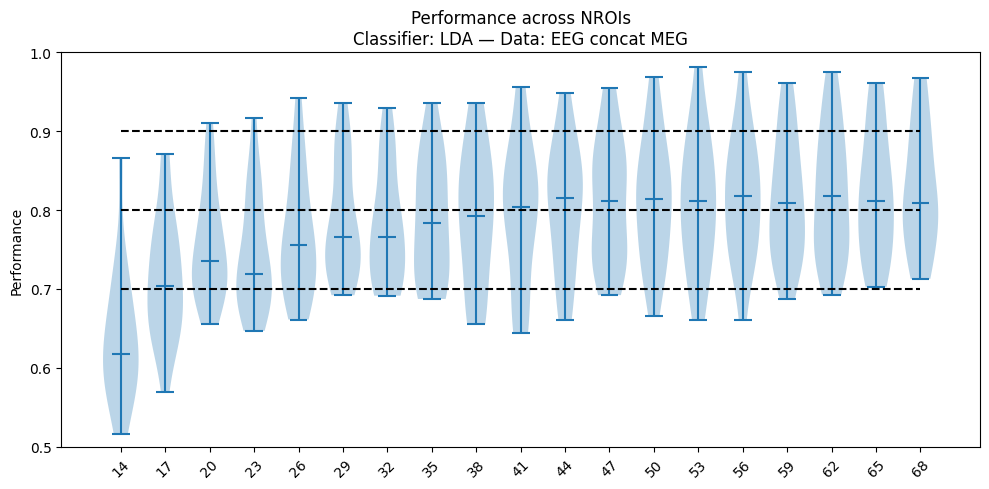

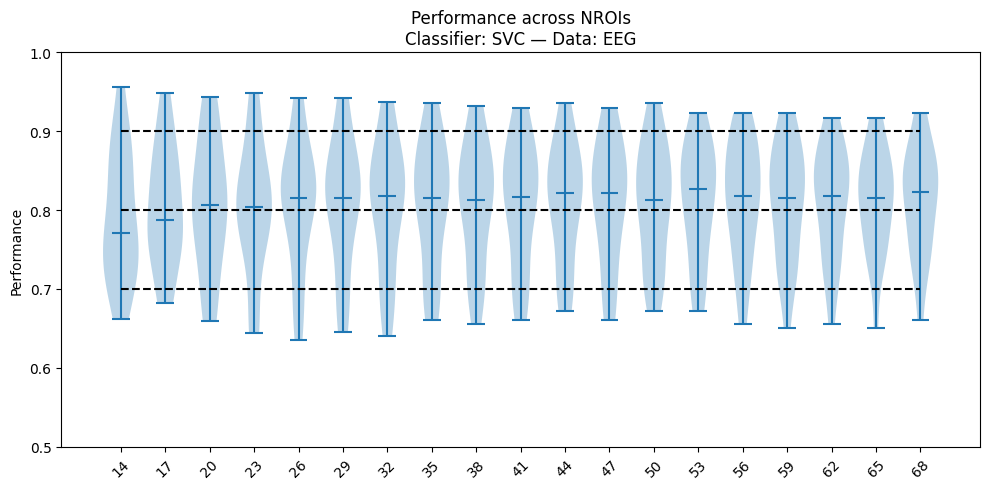

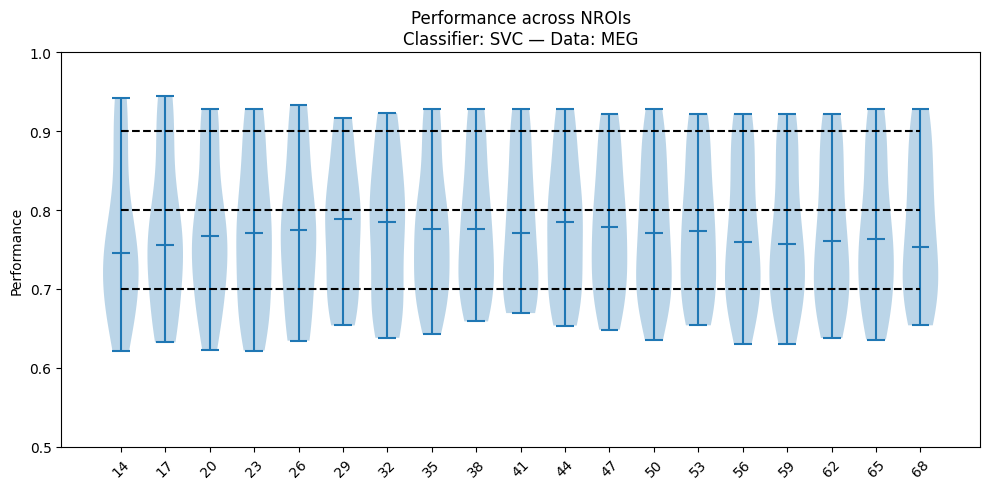

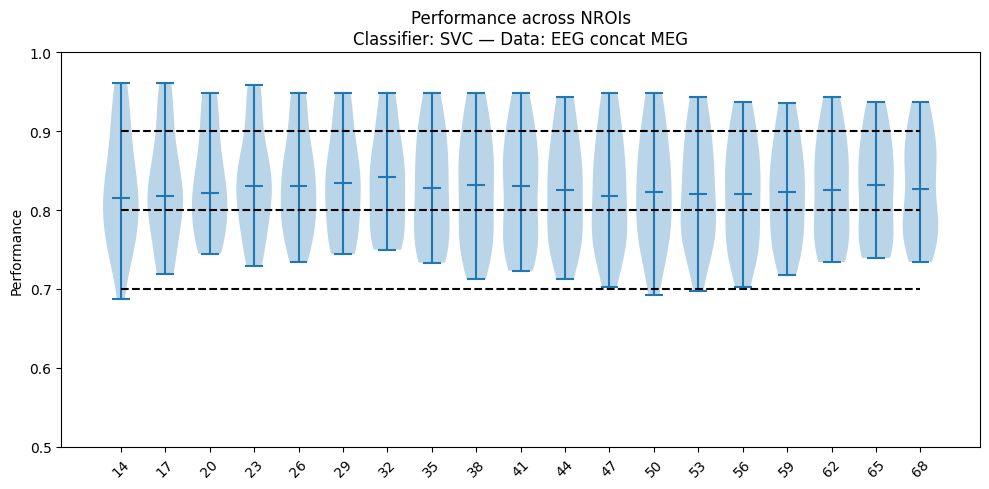

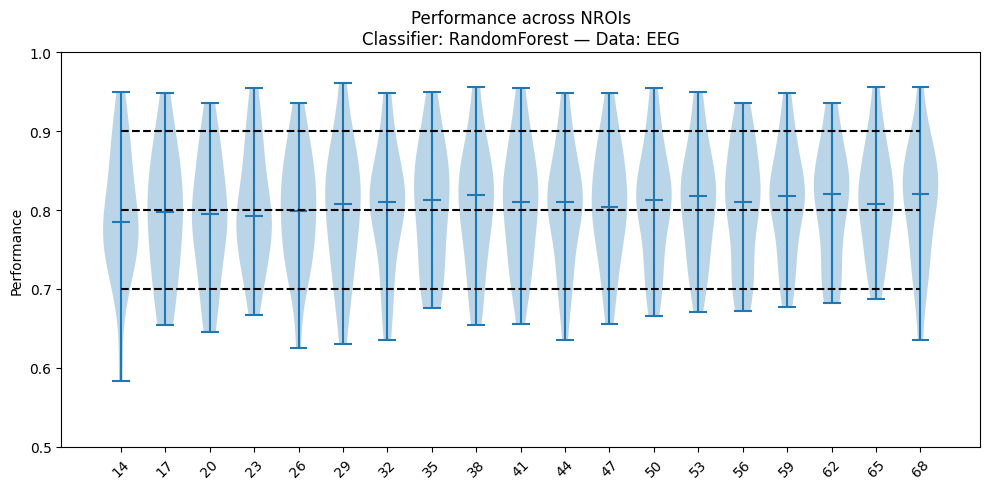

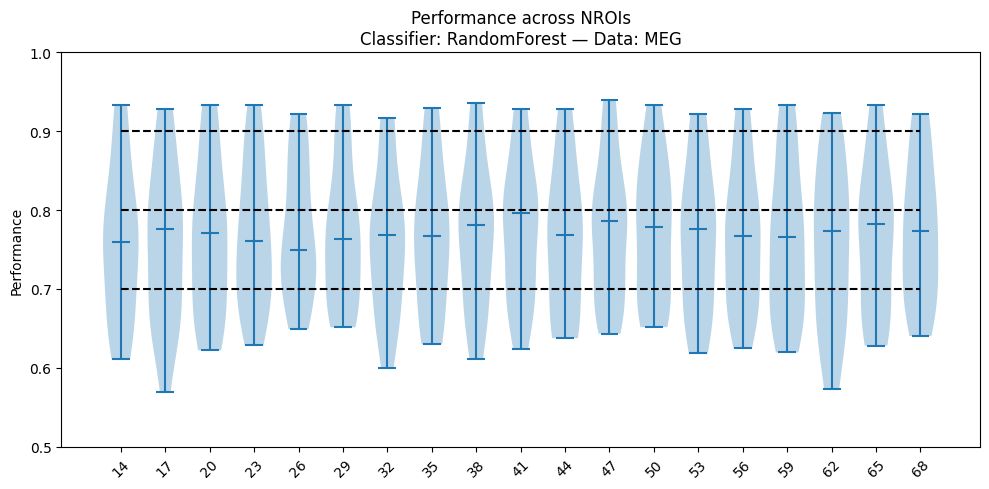

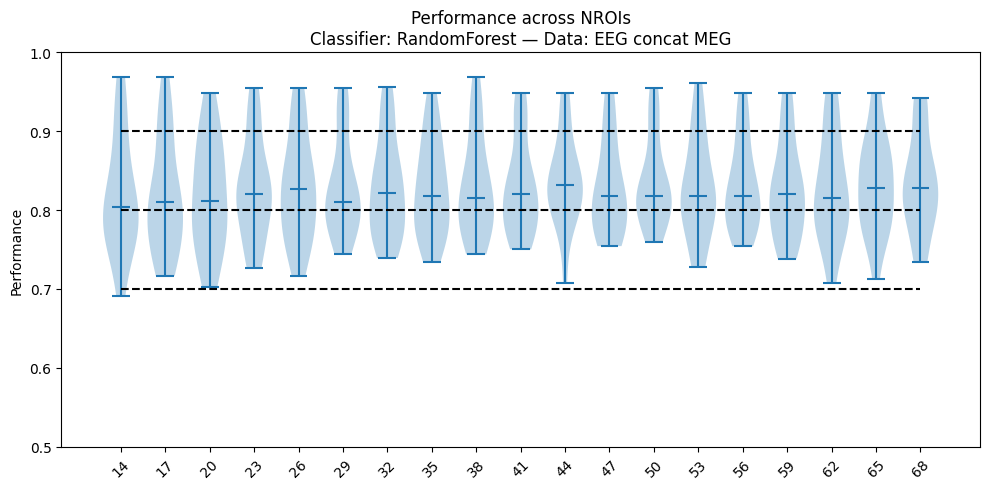

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows

# Load data
PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances.pkl")

# Settings
classifiers = ["LDA","LDA","LDA","SVC","SVC","SVC","RandomForest","RandomForest","RandomForest"]
Datatypes   = ["EEG","MEG","EEG concat MEG","EEG","MEG","EEG concat MEG","EEG","MEG","EEG concat MEG"]

# Vary these
all_NROIs = list(range(14, 69, 3))     # e.g., 14,17,20,...,68
subjects = range(20)

# ============ MAIN PLOT LOOP ============
for setting in range(9):

    clf  = classifiers[setting]
    dtype = Datatypes[setting]

    # Collect performance distributions across NROIs
    # final shape = (len(NROIs), n_subjects)
    all_violins = []

    for NROIs in all_NROIs:
        dict_fixed = {
            "NROIs": NROIs,
            "Personalized_Freq_Range": False
        }

        perfs_for_this_NROIs = []

        for subject in subjects:
            rows = select_rows(
                PerData,
                dict_fixed | {"subject": subject,
                              "Classifier": clf,
                              "DataType": dtype}
            )
            perf = np.array(list(rows["Accuracy"].values)).mean()
            perfs_for_this_NROIs.append(perf)

        all_violins.append(perfs_for_this_NROIs)

    all_violins = np.array(all_violins).T   # shape becomes (subjects, NROIs) for violinplot

    # ================== PLOT =======================
    fig, ax = plt.subplots(figsize=(10, 5))

    positions = np.arange(len(all_NROIs))

    violins = ax.violinplot(
        all_violins,
        positions=positions,
        showmeans=False,
        showmedians=True,
        widths=0.8
    )
    ax.hlines([0.7,0.8,0.9],0,18, color="black", linestyles='dashed')

    # optional: push violins behind scatter or other elements
    for body in violins['bodies']:
        body.set_zorder(-20)

    # Labels
    ax.set_title(f"Performance across NROIs\nClassifier: {clf} — Data: {dtype}")
    ax.set_ylabel("Accuracy")
    ax.set_xticks(positions)
    ax.set_xticklabels(all_NROIs, rotation=45)
    ax.set_ylim(0.5, 1.0)

    plt.tight_layout()
    plt.show()


### Only interesting regions

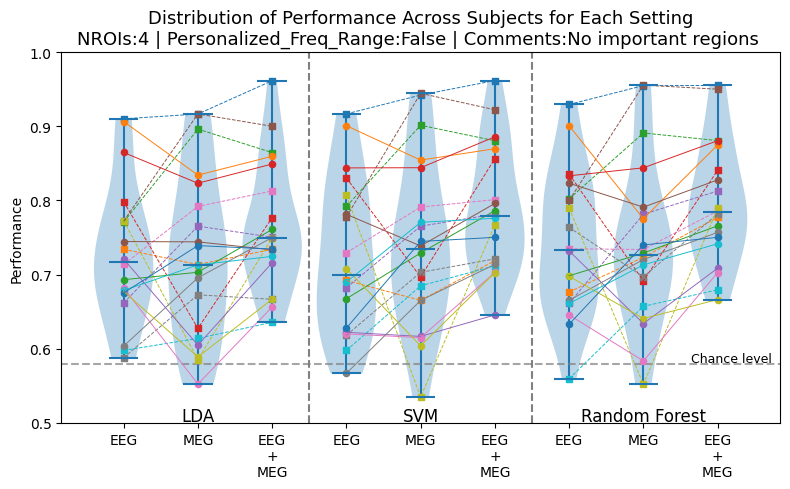

In [ ]:
import pandas as pd

# keys to be selected: 
# DataType,         EEG - MEG - concat (Concat da fare)
# Classifier,       LDA - SVC - Random
# NROIs,            4lh - 4rh - 4lh+4rh - 4free - 8free 
        # Yes important regions - left
        # Yes important regions - right
        # Yes important regions - all
        # No important regions 
# subject, 
# Personalized_Freq_Range

comment="No important regions"# TODO change here 
VisualizigNROIs=4
PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_Important_regions.pkl")
dict_fixed_selection = {"NROIs":VisualizigNROIs,  "Personalized_Freq_Range":False, "Comments":comment}
classifiers=["LDA","LDA","LDA","SVC","SVC","SVC","RandomForest","RandomForest","RandomForest"]
Datatypes=["EEG","MEG","EEG concat MEG","EEG","MEG","EEG concat MEG","EEG","MEG","EEG concat MEG"]
x_ticklabels=[_.replace(" concat ","\n+\n") for _ in Datatypes]
dict_per_setting = {"DataType":Datatypes, "Classifier":classifiers}
textes = ["\nLDA", "\nSVM", "\nRandom Forest"]
textes_x_positions = [.19, .5, .81]
divisioni  = [0,3,6,9]
savepathIMG+"Performance_vs_Setting_no_important_4.png"
plot_violin_all_subj(PerData,  9,  dict_fixed_selection,  dict_per_setting,
                  x_ticklabels,  textes,  textes_x_positions, divisioni,
                  track_subjects=True,  savepath=False)



In [10]:
set(PerData.Comments)

{'No Interesting Regions',
 'No important regions',
 'Only one region',
 'Yes Important Regions',
 'Yes important regions - all',
 'Yes important regions - left',
 'Yes important regions - right'}

## How many times i select a ROI? - Among subjects - Plot on the brain

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows, plot_brain
from matplotlib.colors import LinearSegmentedColormap

# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,
colors = {"EEG":"green","MEG":"blue"}


for DataType in ["EEG",]:
    for NROIs in [17]:#[14,29,41]:
        cmap = LinearSegmentedColormap.from_list("wt", ["white",colors[DataType]])
        
        how_many_times = {}
        

        dict_fixed_selection = {"NROIs":NROIs,"Personalized_Freq_Range":False, "Classifier":"SVC", "DataType":DataType}
        PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances.pkl")
        rows = select_rows(PerData, dict_fixed_selection)

        allRois=[]
        for i in rows["ROIs"].values:
            allRois+=i

        for roi in allRois:
            how_many_times[str(roi)] = how_many_times.get(str(roi), 0) + 1
        for roi in range(68):
            how_many_times[str(roi)] = how_many_times.get(str(roi), 0)

        crs = [cmap(_/20) for _ in how_many_times.values()]

        vvs = ['lateral','medial','rostral','caudal','dorsal']
        my_brain=plot_brain([int(_) for _ in how_many_times.keys()],
                            brain_object_dict={"title":f"{DataType}_NROIs{NROIs}","hemi": "both", "views":vvs}, colors=crs,
                            )
        plotter = my_brain._renderer.plotter

        # STEP 2 — Add text using the plotter (it now applies to renderer 0)
        plotter.add_text(
            f"{DataType}_NROIs{NROIs}",
            position="upper_left",
            font_size=12,
            color="black",
        )

        my_brain.add_text(0,0.5,"fja")

        #my_brain.save_image(savepathIMG+f"Brain_{DataType}_NROIs{NROIs}.png")



Using pyvistaqt 3d backend.
Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/rh.aparc.annot


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows, plot_brain
from matplotlib.colors import LinearSegmentedColormap

# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,
colors = {"EEG":"green","MEG":"blue"}

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_Important_regions.pkl")

for DataType in ["EEG","MEG"]:
    for NROIs in [4,8]:#[14,29,41]:
        cmap = LinearSegmentedColormap.from_list("wt", ["white",colors[DataType]])
        
        how_many_times = {}
        

        dict_fixed_selection = {"NROIs":NROIs,"Personalized_Freq_Range":False, "Classifier":"SVC", "DataType":DataType,"Comments":"No important regions"}
        
        rows = select_rows(PerData, dict_fixed_selection)

        allRois=[]
        for i in rows["ROIs"].values:
            allRois+=i

        for roi in allRois:
            how_many_times[str(roi)] = how_many_times.get(str(roi), 0) + 1
        for roi in range(68):
            how_many_times[str(roi)] = how_many_times.get(str(roi), 0)

        crs = [cmap(_/7) for _ in how_many_times.values()]

        vvs = ['lateral','medial','rostral','caudal','dorsal']
        my_brain=plot_brain([int(_) for _ in how_many_times.keys()],
                            brain_object_dict={"title":f"{DataType}_NROIs_{NROIs}","hemi": "both", "views":vvs}, colors=crs,
                            )
        plotter = my_brain._renderer.plotter

        # STEP 2 — Add text using the plotter (it now applies to renderer 0)
        plotter.add_text(
            f"{DataType}_NROIs_{NROIs}",
            position="upper_left",
            font_size=12,
            color="black",
        )

        #my_brain.add_text(0,0.5,"fja")
        print(DataType, NROIs, max(how_many_times.values()))
        my_brain.save_image(savepathIMG+f"Brain_no_important_regions_{DataType}_NROIs_{NROIs}.png")



Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/rh.aparc.annot
EEG 4 5
Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/rh.aparc.annot
EEG 8 7
Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/rh.aparc.annot
MEG 4 4
Reading labels from parcellation...
   read 35 labels from /Users/giovanni.messuti/mne_data/MNE-sample-data/subjects/fsaverage/label/lh.aparc.annot
   read 34 labels from /Users/giovanni.messuti/m

In [11]:
sum(how_many_times.values())

160

In [10]:
rows

,ROIs,NROIs,DataType,freqs_band,subject,Classifier,Performance,Features,Comments,Date,Personalized_Freq_Range
1661,"[23, 15, 14, 22, 17, 51, 50, 58]",8.0,EEG,"((4, 8), (8, 12), (12, 30))",0.0,SVC,"[0.875, 0.967741935483871, 0.9354838709677419,...",PowerSpectra - MeanMax band,No important regions,2025-12-02,False
1663,"[67, 61, 43, 59, 42, 51, 26, 7]",8.0,EEG,"((4, 8), (8, 12), (12, 30))",1.0,SVC,"[0.7631578947368421, 0.7105263157894737, 0.736...",PowerSpectra - MeanMax band,No important regions,2025-12-02,False
1665,"[42, 14, 43, 23, 26, 27, 48, 6]",8.0,EEG,"((4, 8), (8, 12), (12, 30))",2.0,SVC,"[0.7692307692307693, 0.8205128205128205, 0.815...",PowerSpectra - MeanMax band,No important regions,2025-12-02,False
1667,"[23, 15, 10, 7, 43, 22, 42, 14]",8.0,EEG,"((4, 8), (8, 12), (12, 30))",3.0,SVC,"[0.7368421052631579, 0.868421052631579, 0.8421...",PowerSpectra - MeanMax band,No important regions,2025-12-02,False
1669,"[16, 41, 22, 30, 7, 44, 10, 12]",8.0,EEG,"((4, 8), (8, 12), (12, 30))",4.0,SVC,"[0.5641025641025641, 0.5897435897435898, 0.736...",PowerSpectra - MeanMax band,No important regions,2025-12-02,False
1671,"[33, 32, 44, 56, 11, 55, 28, 10]",8.0,EEG,"((4, 8), (8, 12), (12, 30))",5.0,SVC,"[0.7777777777777778, 0.8611111111111112, 0.666...",PowerSpectra - MeanMax band,No important regions,2025-12-02,False
1673,"[48, 36, 56, 44, 49, 45, 54, 24]",8.0,EEG,"((4, 8), (8, 12), (12, 30))",6.0,SVC,"[0.7692307692307693, 0.6153846153846154, 0.736...",PowerSpectra - MeanMax band,No important regions,2025-12-02,False
1675,"[7, 59, 49, 45, 15, 50, 33, 42]",8.0,EEG,"((4, 8), (8, 12), (12, 30))",7.0,SVC,"[0.696969696969697, 0.6666666666666666, 0.7272...",PowerSpectra - MeanMax band,No important regions,2025-12-02,False
1677,"[23, 26, 15, 43, 22, 27, 6, 34]",8.0,EEG,"((4, 8), (8, 12), (12, 30))",8.0,SVC,"[0.7777777777777778, 0.8, 0.8, 0.7142857142857...",PowerSpectra - MeanMax band,No important regions,2025-12-02,False
1679,"[65, 55, 53, 31, 59, 23, 61, 7]",8.0,EEG,"((4, 8), (8, 12), (12, 30))",9.0,SVC,"[0.6216216216216216, 0.6486486486486487, 0.702...",PowerSpectra - MeanMax band,No important regions,2025-12-02,False


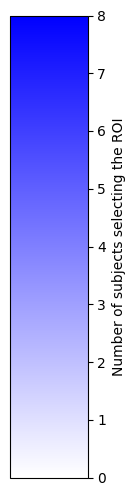

In [13]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.colorbar import ColorbarBase

cmap = LinearSegmentedColormap.from_list("white_to_green", ["white", "blue"])
norm = Normalize(vmin=0, vmax=8)
fig, ax = plt.subplots(figsize=(1, 6))  # tall figure for vertical colorbar
ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical', label='Number of subjects selecting the ROI')
#plt.show()
plt.savefig(f"{savepathIMG}colorbar_white_to_blue_max8.png", dpi=300, bbox_inches='tight')


## Frequencies selection

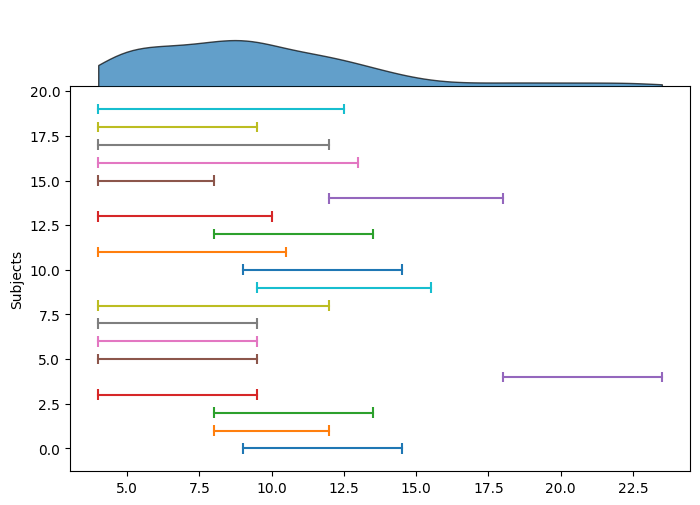

In [31]:
import matplotlib.pyplot as plt
import numpy as np

freq_personalized = {
    "subject_0":[9,14.5], "subject_1":[8,12], "subject_2":[8,13.5],
    "subject_3":[4,9.5], "subject_4":[18,23.5], "subject_5":[4,9.5],
    "subject_6":[4,9.5], "subject_7":[4,9.5], "subject_8":[4,12],
    "subject_9":[9.5,15.5], "subject_10":[9,14.5], "subject_11":[4,10.5],
    "subject_12":[8,13.5], "subject_13":[4,10.], "subject_14":[12,18],
    "subject_15":[4,8], "subject_16":[4,13], "subject_17":[4,12],
    "subject_18":[4,9.5], "subject_19":[4,12.5],
}

# Flatten all frequency ranges for cumulative violin
all_freqs = []
for subj in freq_personalized.values():
    all_freqs.extend(np.linspace(subj[0], subj[1], 50))
all_freqs = np.array(all_freqs)

fig, ax_main = plt.subplots(1,1, figsize=(8,5))
# Main plot: individual subjects
for subject in range(20):
    ax_main.plot(freq_personalized[f"subject_{subject}"], [subject,subject], color=f"C{subject}")
    ax_main.vlines(freq_personalized[f"subject_{subject}"], subject-0.3, subject+0.3, color=f"C{subject}")
ax_main.set_ylabel("Subjects")



# Create twin axis sharing x-axis but at the bottom
ax_violin = ax_main.inset_axes([0,1, 1, 0.2])  # x0, y0, width, height in axis fraction

viol = ax_violin.violinplot(all_freqs, positions=[0], widths=1.2,
                            showmeans=False, showmedians=False, showextrema=False, vert=False)

for i, body in enumerate(viol['bodies']):
    verts = body.get_paths()[0].vertices
    if i == 0:
        # one half
        verts[:,1] = np.clip(verts[:,1], 0, None)
        body.set_facecolor('C0')
    else:
        # other  half
        verts[:,1] = np.clip(verts[:,1], None, 0)
        body.set_facecolor('C0')
    body.set_edgecolor('black')
    body.set_alpha(0.7)

ax_violin.set_yticks([])
ax_violin.set_xticks([])
ax_violin.set_ylim(0,1)
# ax_violin.set_xlabel("Frequencies (Hz)")
ax_violin.set_xlim(ax_main.get_xlim())
ax_violin.set_frame_on(False)


plt.show()


# Starting on 12 / 2025 -  Different region selection criteria


## Plot Per Subject

### Vs regions

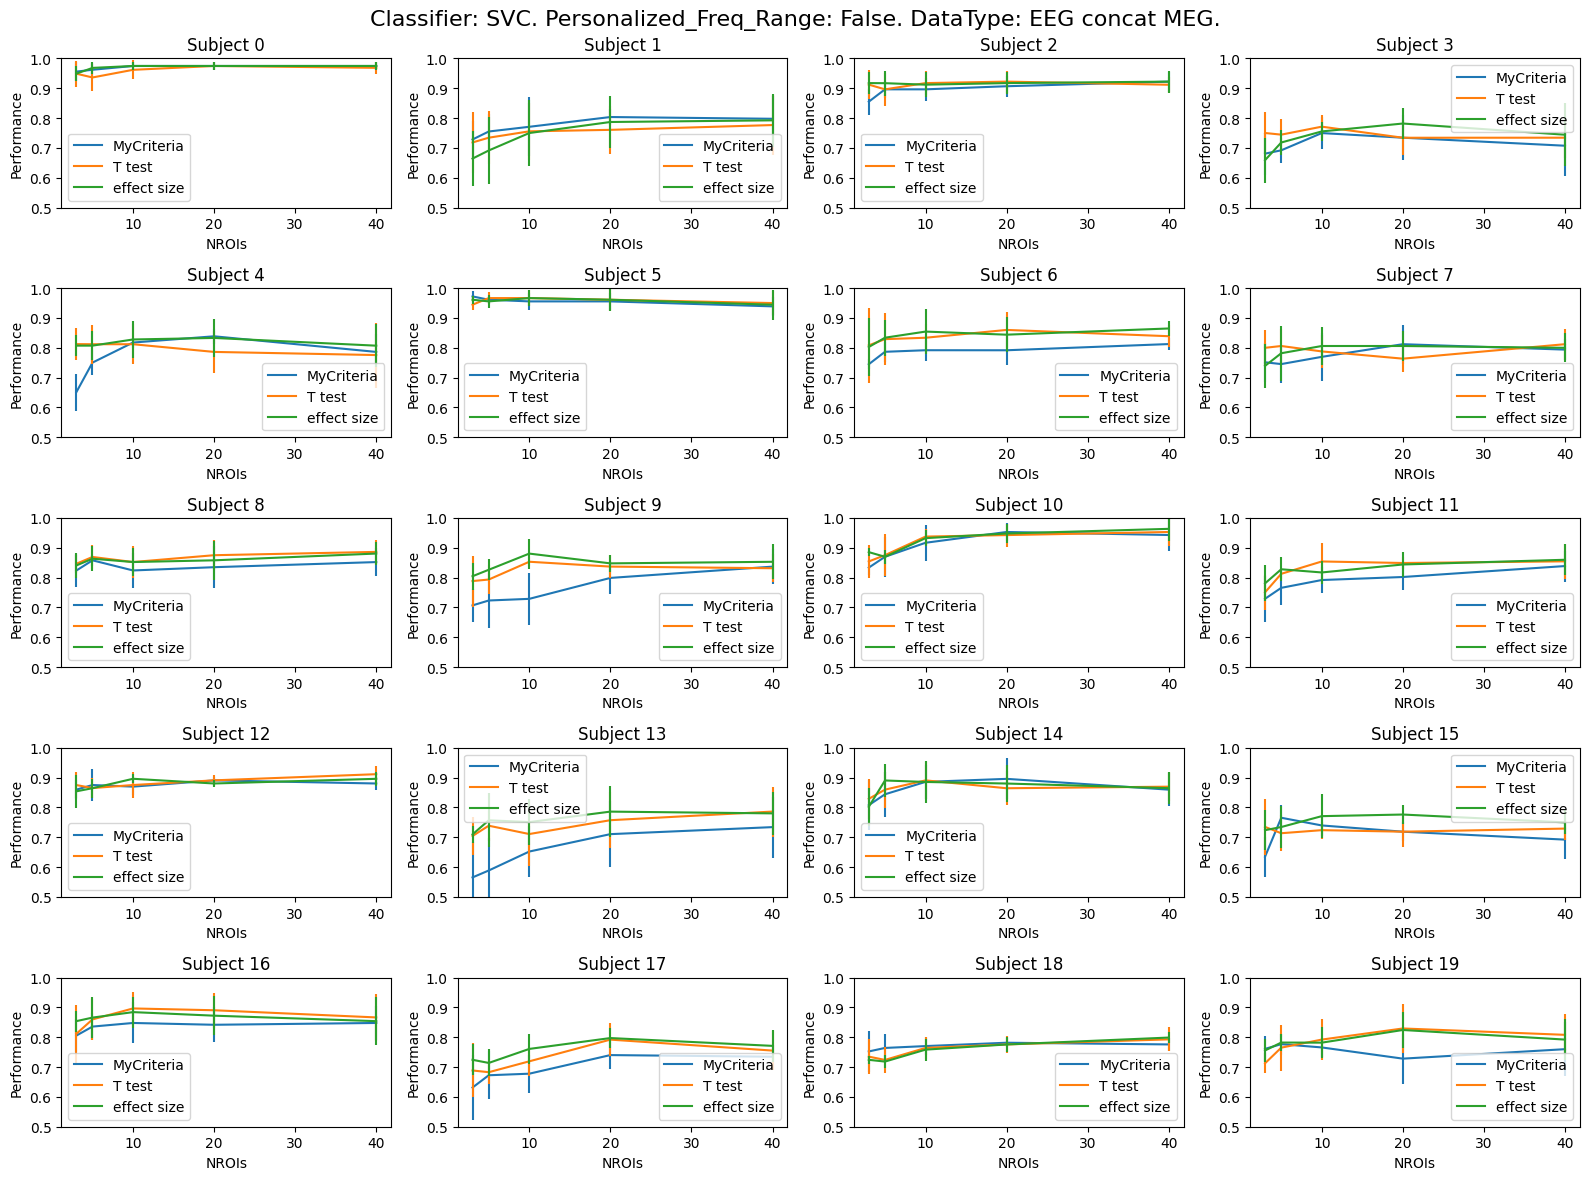

In [ ]:
# Different selections vs ROIs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
dict_fixed_selection = {"Classifier":"SVC","Personalized_Freq_Range":False,"DataType":"EEG concat MEG"}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject,  "Comments":"MyCriteria selection"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="MyCriteria")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C0')
    

    
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject,  "Comments": "T test selection mean power alpha beta"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="T test")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1')

    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject,  "Comments": "Cohen's d effect size selection"})
    allperf = np.array(list(rows["Accuracy"].values))
    nrois = rows["NROIs"].values
    ax.plot(nrois, allperf.mean(axis=1),label="effect size")
    ax.vlines(nrois, allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C2')




    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}")
    ax.set_xlabel("NROIs")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
#plt.savefig(savepathIMG+"EEG_concat_MEG_vs_EEG_vs_MEG_SVM.png")
plt.show()

### Only 1 REGION

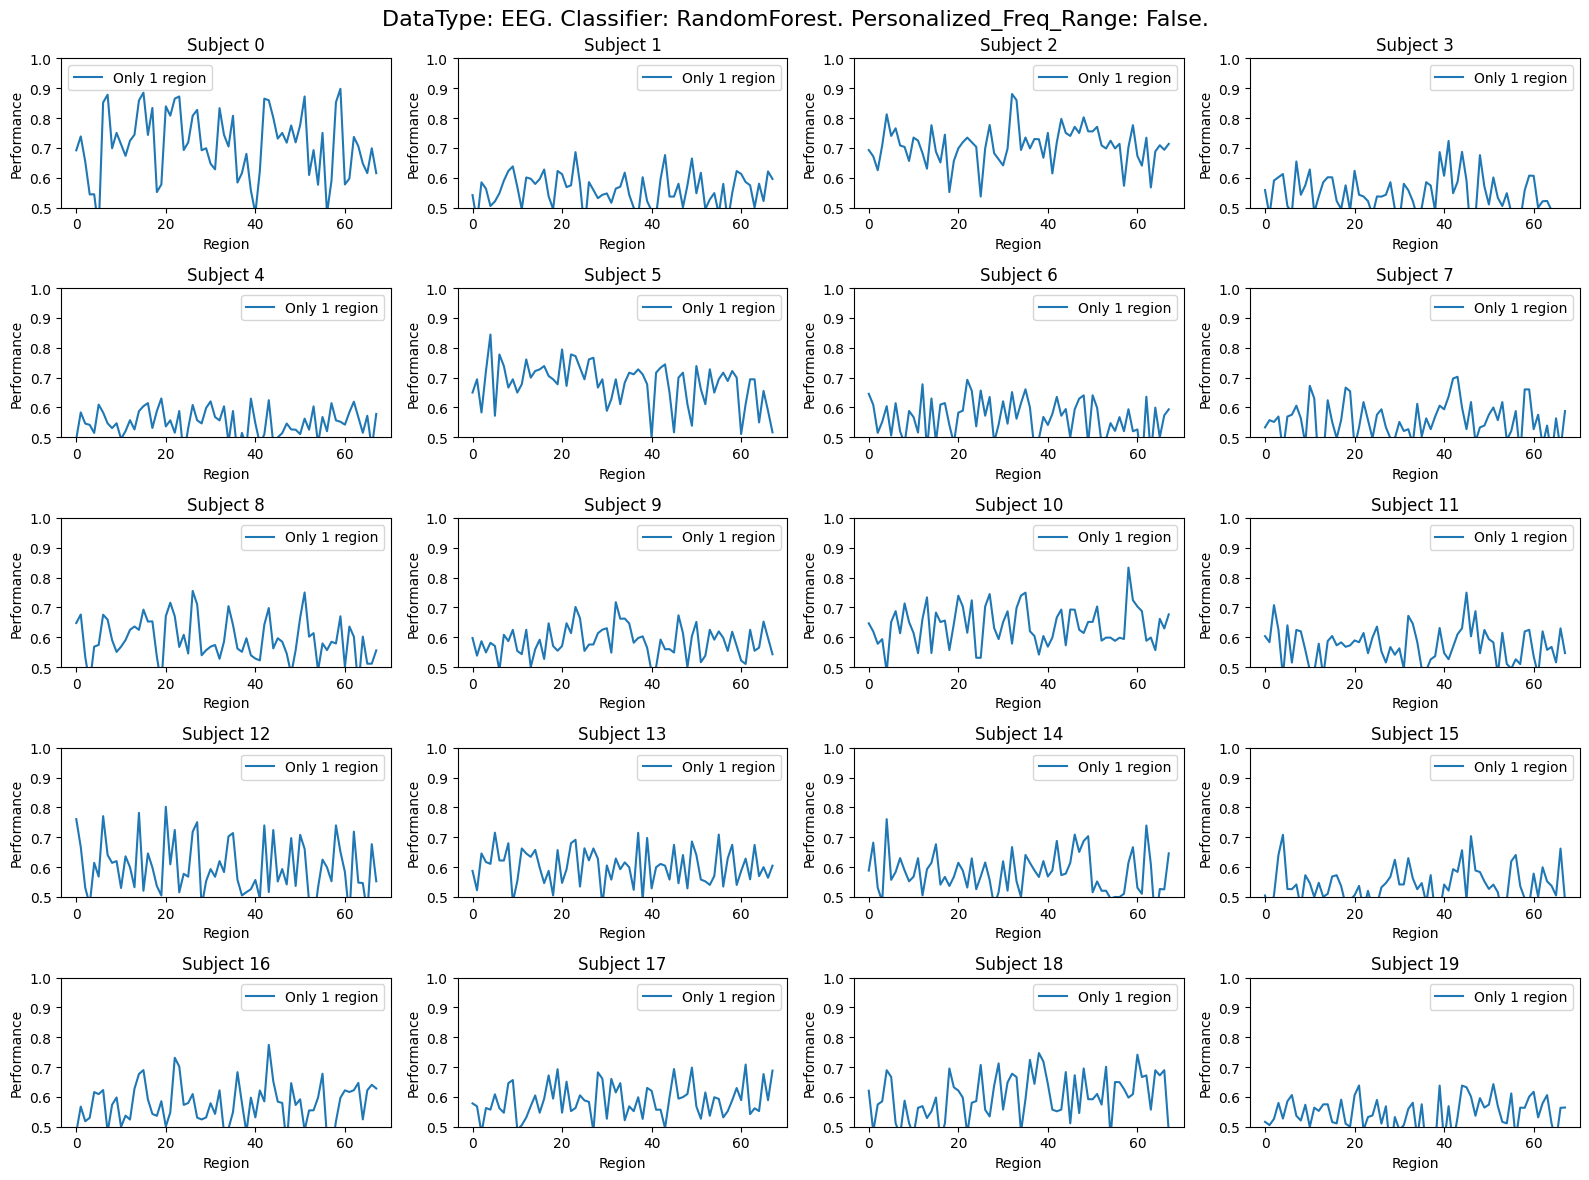

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_on_single_region.pkl")

fig, axes = plt.subplots(5, 4, figsize=(16, 12))
axes = axes.flatten()

#    |
allallperf = []
dict_fixed_selection = {"DataType":"EEG", "Classifier":"RandomForest", "Personalized_Freq_Range":False}
for subject in range(20):
    ax = axes[subject]

    # Extract performances
    rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Comments":"-"})
    allperf = np.array(list(rows["Accuracy"].values))
    allallperf.append(allperf.mean(axis=1))
    nrois = rows["NROIs"].values
    ax.plot( allperf.mean(axis=1),label="Only 1 region")
    #ax.vlines( [i for i in range(68)], allperf.mean(axis=1)-allperf.std(axis=1), allperf.mean(axis=1)+allperf.std(axis=1), colors='C1',linestyle="--",alpha=0.8)


    ax.set_ylim(0.5, 1)
    ax.set_title(f"Subject {subject}")
    ax.set_xlabel("Region")
    ax.set_ylabel("Accuracy")
    ax.legend()

plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()
#plt.savefig(savepathIMG+"freq_personalized_vs_not_SVM.png")
plt.show()

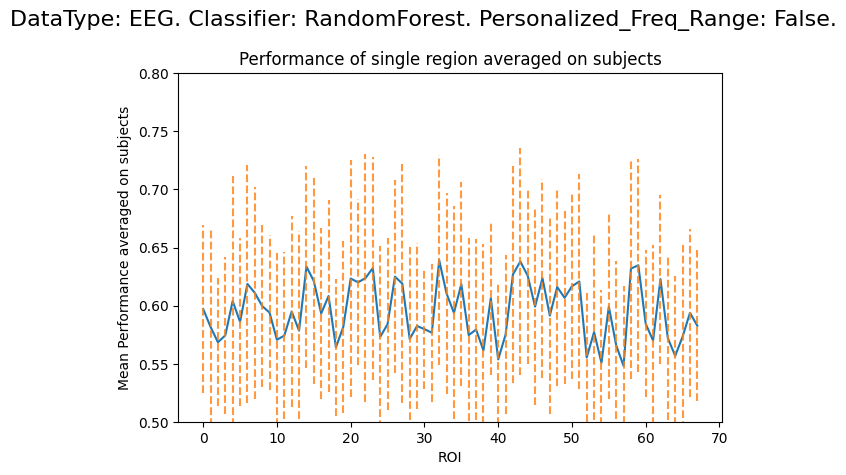

In [33]:
# Averaged over subjects
allallperf=np.array(allallperf)
plt.plot(allallperf.mean(axis=0))
plt.vlines( [i for i in range(68)], allallperf.mean(axis=0)-allallperf.std(axis=0), allallperf.mean(axis=0)+allallperf.std(axis=0), colors='C1',linestyle="--",alpha=0.8)


plt.ylim(0.5, 0.8)
plt.title(f"Performance of single region averaged on subjects")
plt.xlabel("ROI")
plt.ylabel("Mean Performance averaged on subjects")


plt.suptitle(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]), fontsize=16)
plt.tight_layout()


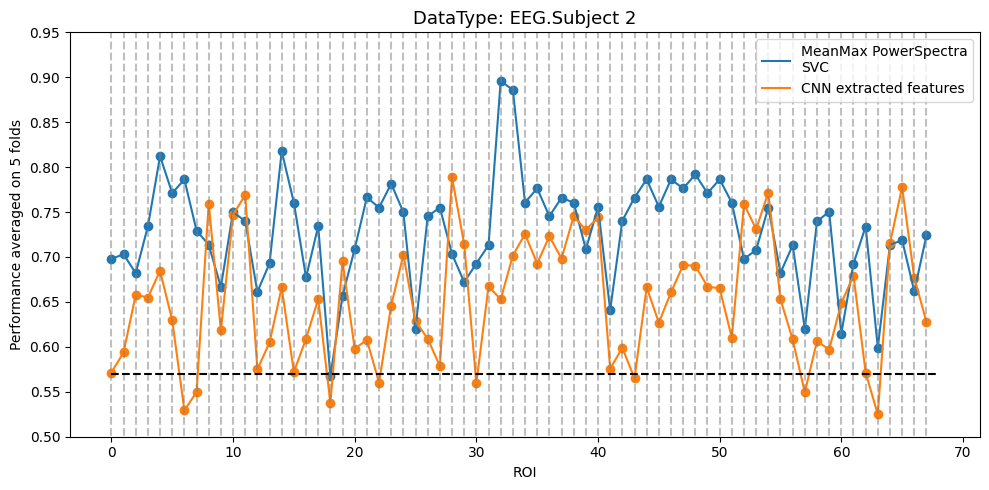

In [ ]:
# Comparison with Deep Learning! 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows
# keys to be selected: 
# DataType,
# Classifier,
# subject, 
# Personalized_Freq_Range
# NROIs,

subject = 2
PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_on_single_region.pkl")

#    |
dict_fixed_selection = {"DataType":"EEG"}

# Extract performances
rows = select_rows(PerData, dict_fixed_selection | {"subject":subject, "Comments":"-", "Personalized_Freq_Range":False , "Classifier":"SVC"})
perf_powerSpectra_performances = np.array(list(rows["Accuracy"].values))


fig, axes = plt.subplots(1, 1, figsize=(10, 5))

Classic_Perf = perf_powerSpectra_performances.mean(axis=1)
axes.plot(Classic_Perf, label="MeanMax PowerSpectra\nSVC")
axes.scatter([_ for _ in range(68)],Classic_Perf)

DL_performance = pd.read_pickle("../_Deep_Learning/Models_trained/2026-01-24-11_51_50_First_Try/aggregated_region_performance.pkl")

DL_perf = DL_performance["accuracy"].apply(np.mean)
axes.plot(DL_perf, label="CNN extracted features")
axes.scatter([_ for _ in range(68)],DL_perf)
axes.legend()

axes.vlines([_ for _ in range(68)], 0, 1, colors='gray', linestyles='dashed', alpha=0.5)
axes.set_ylim(0.5, 0.95)
axes.set_title(" ".join([f"{_}: {__}."  for _,__ in dict_fixed_selection.items()]) + f"Subject 2",fontsize=13)
axes.set_xlabel("ROI")
axes.set_ylabel("Performance averaged on 5 folds")
axes.hlines([0.57],0,68, color="black", linestyles='dashed')
fig.tight_layout()

(0.4, 1.0)

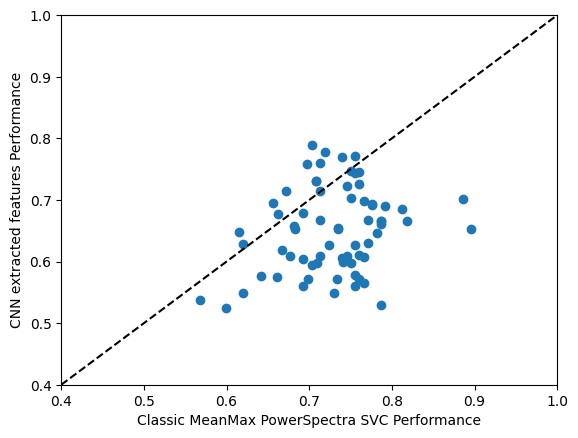

In [ ]:
plt.scatter(Classic_Perf, DL_perf.to_numpy()) 
plt.plot([0.4, 1], [0.4, 1], color="black", linestyle="--")
plt.xlabel("Classic MeanMax PowerSpectra SVC Accuracy")
plt.ylabel("CNN extracted features Accuracy")
plt.xlim(0.4, 1)
plt.ylim(0.4, 1)

In [52]:
import numpy as np
corr_matrix = np.corrcoef(Classic_Perf, DL_perf.to_numpy()) 
corr = corr_matrix[0, 1] 
print(corr_matrix)

[[1.        0.2421678]
 [0.2421678 1.       ]]


In [58]:
from scipy.stats import spearmanr

spearmanr(Classic_Perf, DL_perf.to_numpy()) 

SignificanceResult(statistic=np.float64(0.19947511579487973), pvalue=np.float64(0.10292129641336704))

## Plot All subjects

### Different criteria

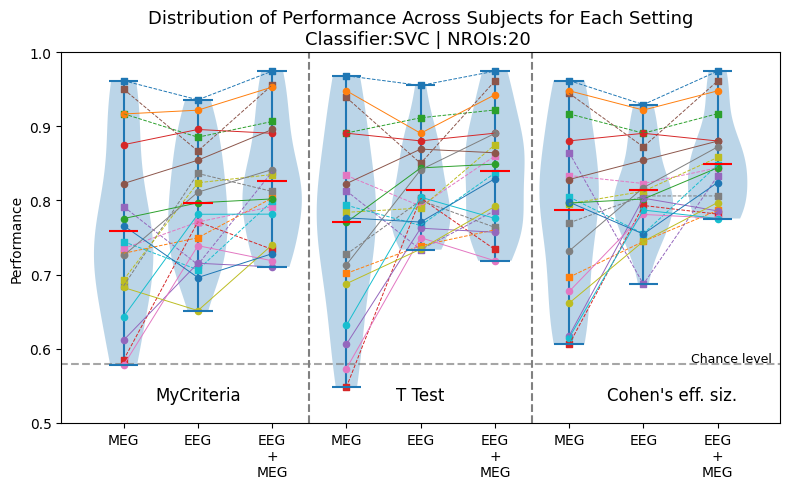

In [ ]:
import pandas as pd

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")
VisualizigNROIs = 20
dict_fixed_selection = {"Classifier":"SVC", "NROIs":VisualizigNROIs}
divisioni = [0,3,6,9]
textes = ["MyCriteria","T Test", "Cohen's eff. siz."]
textes_x_positions = [.19, .5, .85]
Datatypes = ["MEG","EEG","EEG concat MEG"]*3
Comments = ["MyCriteria selection"]*3  +  ["T test selection mean power alpha beta"]*3 + ["Cohen's d effect size selection"]*3 #"Cohen's d effect size selection spectra starting from 3s"
x_ticklabels = [_.replace(" concat ","\n+\n") for _ in Datatypes]
dict_per_setting = {"DataType":Datatypes, "Comments":Comments}
plot_violin_all_subj(PerData,  9,  dict_fixed_selection,  dict_per_setting,
                  x_ticklabels,  textes,  textes_x_positions, 
                  divisioni, hlines_positions=[],
                  track_subjects=True,  savepath=False)


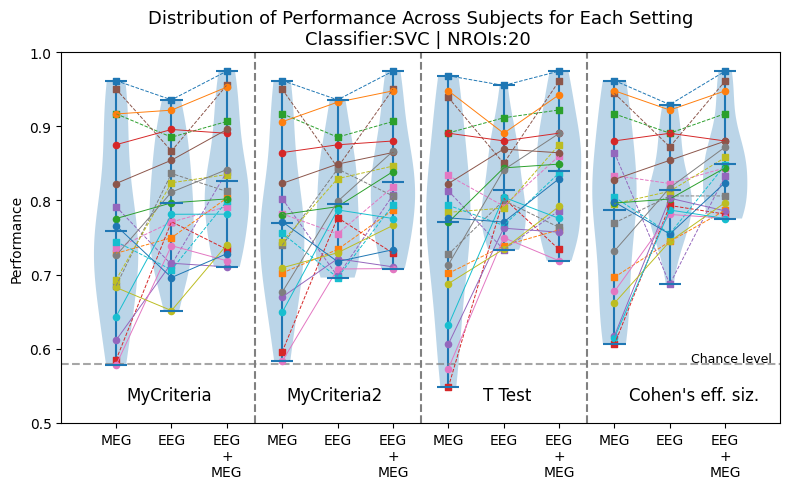

In [ ]:
import pandas as pd

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")
VisualizigNROIs = 20
dict_fixed_selection = {"Classifier":"SVC", "NROIs":VisualizigNROIs}
divisioni = [0,3,6,9,12]
textes = ["MyCriteria", "MyCriteria2", "T Test", "Cohen's eff. siz."]
textes_x_positions = [.15, .38, .62, .88]
Datatypes = ["MEG","EEG","EEG concat MEG"]*4
Comments = ["MyCriteria selection"]*3  + ["MyCriteria2 selection"]*3  + ["T test selection mean power alpha beta"]*3 + ["Cohen's d effect size selection"]*3 #"Cohen's d effect size selection spectra starting from 3s"
x_ticklabels = [_.replace(" concat ","\n+\n") for _ in Datatypes]
dict_per_setting = {"DataType":Datatypes, "Comments":Comments}
plot_violin_all_subj(PerData,  12,  dict_fixed_selection,  dict_per_setting,
                  x_ticklabels,  textes,  textes_x_positions, 
                  divisioni, hlines_positions=[],
                  track_subjects=True,  savepath=False)


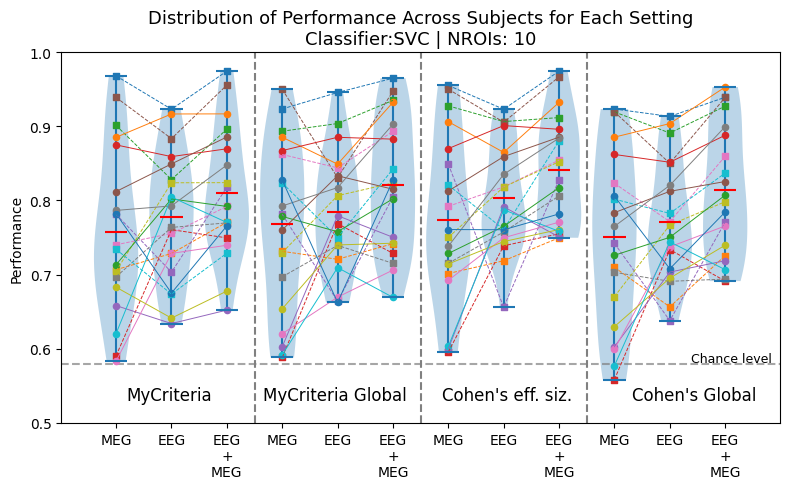

In [ ]:
import pandas as pd
savepathIMG = "../Images/"
from BCI_Library import plot_violin_all_subj, plot_violin_track_single_fold

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")
PerData10 = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_region_selection_on_repeated_10folds_8_30_Hz.pkl")
PerData["newcol"] = 1
PerData10["newcol"] = 10

combined = pd.concat([PerData, PerData10], ignore_index=True)

VisualizigNROIs = 10
dict_fixed_selection = {"Classifier":"SVC"}

divisioni = [0,3,6,9,12]
Datatypes = ["MEG","EEG","EEG concat MEG"]*4

Comments = ["MyCriteria selection"]*3  + ["Global Selection - MyCriteria based"]*3  + ["Cohen's d effect size selection"]*3 +["Global Selection - Cohen based"]*3 #"Cohen's d effect size selection spectra starting from 3s"
newcol = [1]*3 + [10]*3 + [1]*3 + [10]*3 
NROIs = [10]*3 + [11] + [9]*2 + [10]*3 + [10]*3
dict_per_setting = {"DataType":Datatypes, "Comments":Comments, "NROIs":NROIs, "newcol":newcol}

x_ticklabels = [_.replace(" concat ","\n+\n") for _ in Datatypes]
textes = ["MyCriteria", "MyCriteria Global", "Cohen's eff. siz.",  "Cohen's Global"]
textes_x_positions = [.15, .38, .62, .88]

plot_violin_all_subj(combined,  12,  dict_fixed_selection,  dict_per_setting,
                  x_ticklabels,  textes,  textes_x_positions, 
                  divisioni, hlines_positions=[],
                  track_subjects=True,  savepath=False,
                  additional_title="| NROIs: 10")


### Vs N ROIs

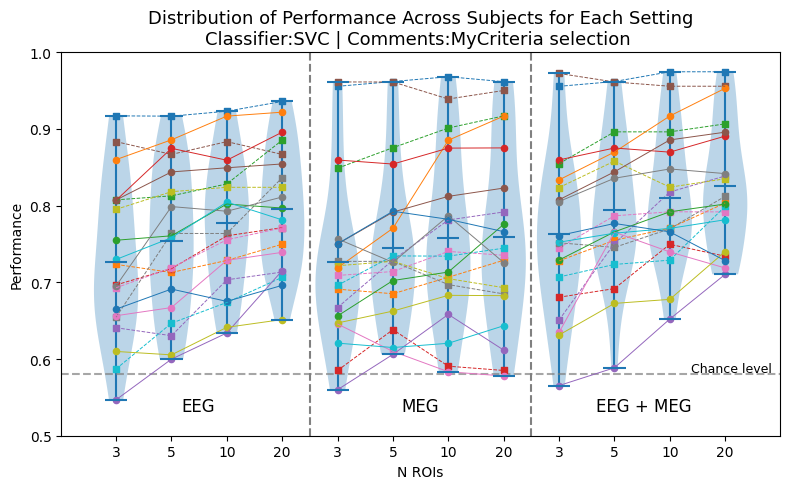

In [ ]:
import pandas as pd

PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")
VisualizigNROIs=20
dict_fixed_selection = {"Classifier":"SVC", "Comments":"MyCriteria selection"} #
divisioni = [0,4,8,12]
VisualizigNROIs=[3,5,10,20]
Datatypes=["EEG"]* len(VisualizigNROIs) + ["MEG"]* len(VisualizigNROIs) + ["EEG concat MEG"]* len(VisualizigNROIs)
VisualizigNROIs=VisualizigNROIs*3 # 3 is Datatype

dict_per_setting = {"NROIs":VisualizigNROIs, "DataType":Datatypes}
x_ticklabels=[_ for _ in VisualizigNROIs]
textes = ["EEG", "MEG", "EEG + MEG"]
textes_x_positions = [.19,.5,.81]

plot_violin_all_subj(PerData,  12,  dict_fixed_selection,  dict_per_setting,
                  x_ticklabels,  textes,  textes_x_positions,
                  divisioni, xlabel="N ROIs",
                  track_subjects=True,  savepath=False)


### 10 k-folds

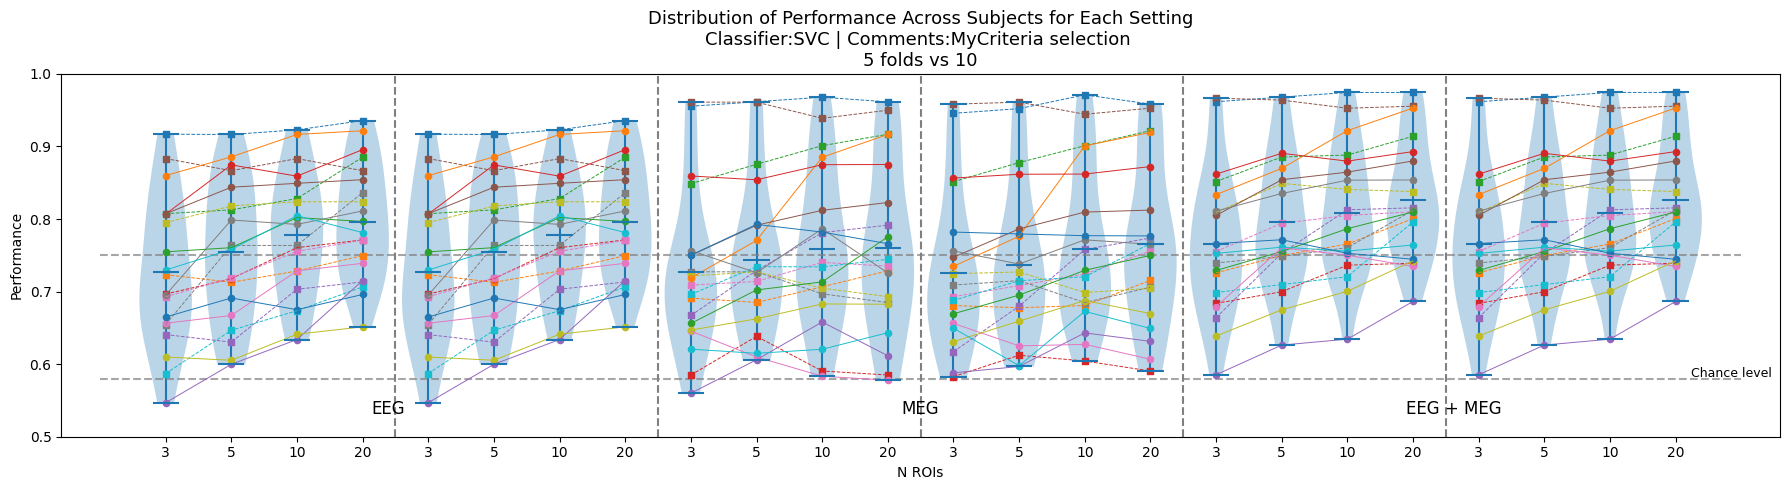

In [ ]:
# 10 folds vs 5 folds

import pandas as pd

PerData2 = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_region_selection_on_repeated_10folds_8_30_Hz.pkl")
PerData = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")
PerData["newcol"] = 1
PerData2["newcol"] = 2

combined = pd.concat([PerData, PerData2], ignore_index=True)


VisualizigNROIs=20
dict_fixed_selection = {"Classifier":"SVC", "Comments":"MyCriteria selection"}
divisioni = [0,4,8,12, 16,20,24]
VisualizigNROIs=[3,5,10,20]
Datatypes = ["EEG"]* len(VisualizigNROIs)*2 + ["MEG"]* len(VisualizigNROIs)*2 + ["EEG concat MEG"]* len(VisualizigNROIs)*2

VisualizigNROIs=VisualizigNROIs*6 # 3 is Datatype, 2 is PerData e PerData2

newcol=[1]*12 + [2]*12
dict_per_setting = {"NROIs":VisualizigNROIs, "DataType":Datatypes, "newcol":newcol}

x_ticklabels=[_ for _ in VisualizigNROIs]
textes = ["EEG", "MEG", "EEG + MEG"]
textes_x_positions = [.19,.5,.81, ]

plot_violin_all_subj(combined,  24,  dict_fixed_selection,  dict_per_setting,
                  x_ticklabels,  textes,  textes_x_positions,
                  divisioni, xlabel="N ROIs", hlines_positions=[0.75],
                  track_subjects=True,  savepath=False, figsize=(18,5), additional_title="\n5 folds vs 10")

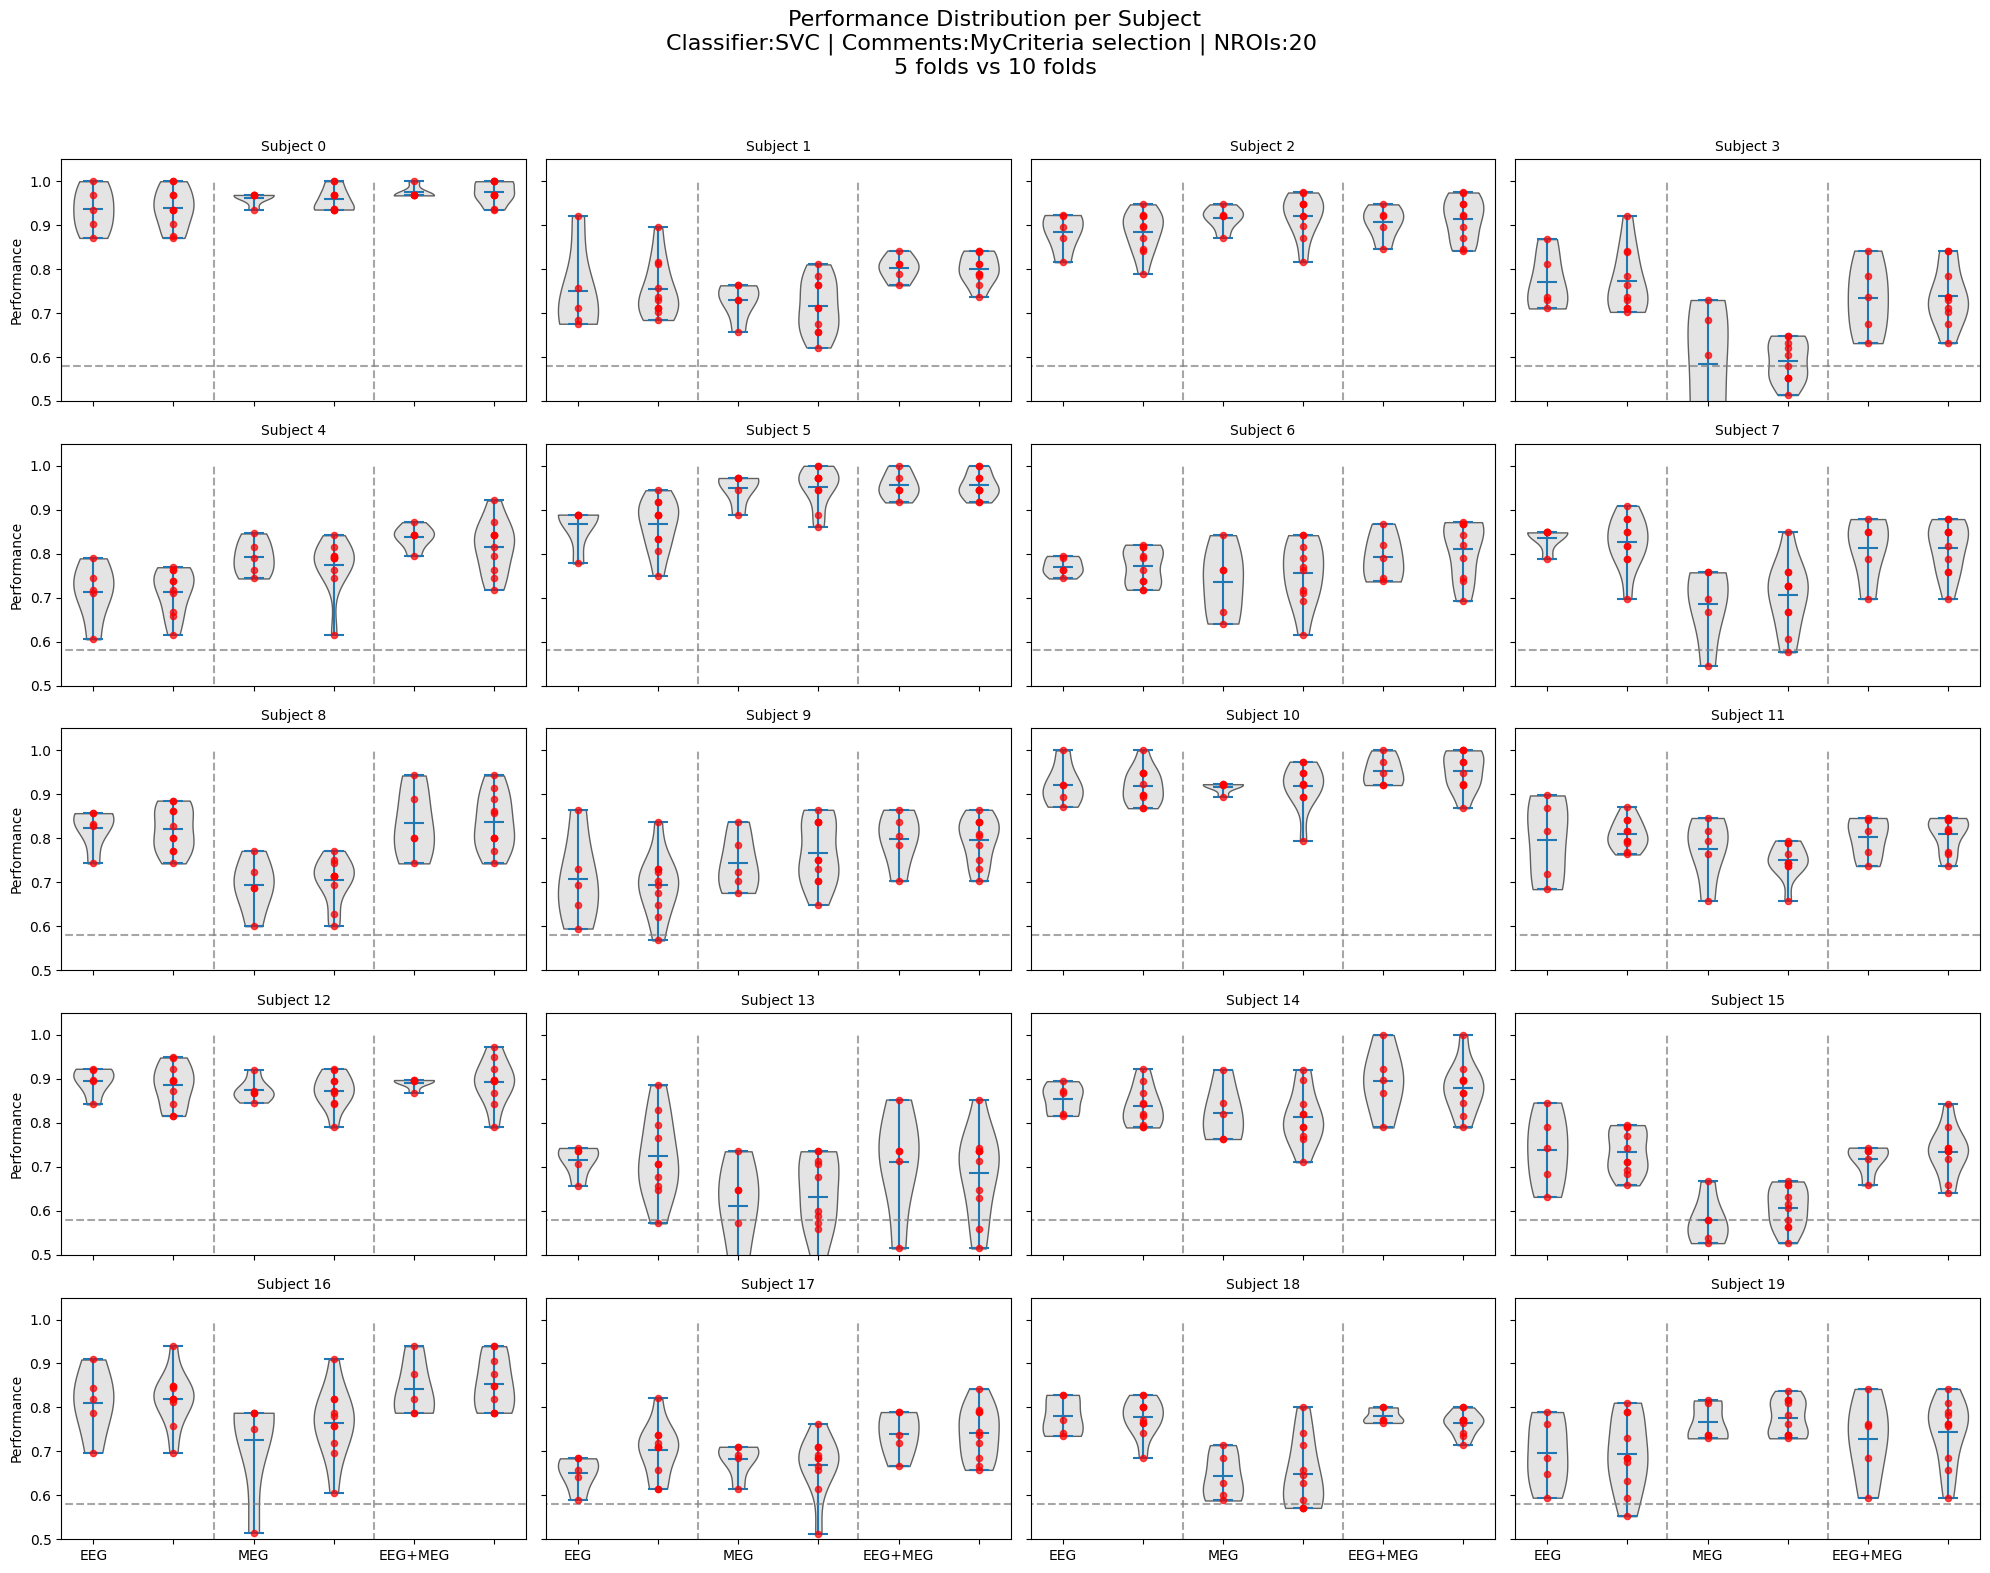

In [ ]:
import pandas as pd
PerformanceData5 = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")
PerformanceData10 = pd.read_pickle("../Results/BCI_Performances/BCI_Performances_region_selection_on_repeated_10folds_8_30_Hz.pkl")
from BCI_Library import plot_violin_all_subj, plot_violin_track_single_fold
PerformanceData5["newcol"] = 5
PerformanceData10["newcol"] = 10

newcol = [5,10]*3
concate = pd.concat([PerformanceData5,PerformanceData10], ignore_index=True)

num_settings_showed_per_subject = 6
dict_fixed_selection = {
    "Classifier": "SVC",
    "Comments": "MyCriteria selection",
    "NROIs": 20,
}
Datatypes = ["EEG", "EEG", "MEG","MEG", "EEG concat MEG","EEG concat MEG"]
dict_per_setting = {"DataType": Datatypes, "newcol":newcol}
x_ticklabels = ["EEG","", "MEG","", "EEG+MEG",""]
pfs = plot_violin_track_single_fold(concate, num_settings_showed_per_subject, dict_fixed_selection, dict_per_setting, 
                                    x_ticklabels, additional_title="\n5 folds vs 10 folds",vlines_positions=[1.5,3.5])

## Brain plots

### All subject - cumulative

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows, plot_brain, read_ranks_subect, sort_rank
from matplotlib.colors import LinearSegmentedColormap
import os

subjects_dir = 'C:\\Users\\Dell_i5\\mne_data\\MNE-sample-data' + "\\subjects"
os.environ["SUBJECTS_DIR"] = subjects_dir
print("SUBJECTS_DIR set to:", subjects_dir)

colors = {"EEG":"green","MEG":"blue"}
Interesting_regions_right =   [5, 33, 45, 49]
Interesting_regions_left = [4, 32, 44, 48,]


for DataType in ["EEG","MEG"]: #["EEG","MEG"]:
    for N_best_ROIs in[5,10,20,30]:  #[5,10,20,30]:
        cmap = LinearSegmentedColormap.from_list("wt", ["white",colors[DataType]])
        
        how_many_times = {}
        for regione in range(68):
            how_many_times[regione] = 0
        num_subj_at_least_1_right, num_subj_at_least_1_left = (0,0)
        for subject in range(20):
            ranks_subject = read_ranks_subect("../Results/RegionSelection/" \
            f"Selected_regions_MultiTtest_on_mean_alpha_beta_{DataType}_among_5_folds_training_selected.pkl", subject, read_all_trials=True)[0]

            at_least_1_left, at_least_1_right = (0,0)
            for migiori_regioni in range(N_best_ROIs):
                regione_ora = ranks_subject[migiori_regioni]
                how_many_times[regione_ora] +=  1 
                # controllo se nel soggetto ha almeno 1 regione tra quelle importanti di destra o sinistra
                if regione_ora in Interesting_regions_left:
                    at_least_1_left = 1
                    #print(subject, regione_ora)
                if regione_ora in Interesting_regions_right:
                    at_least_1_right = 1

            num_subj_at_least_1_right += at_least_1_right
            num_subj_at_least_1_left += at_least_1_left

                

        crs = [cmap(_/max(how_many_times.values())) for _ in how_many_times.values()]

        vvs = ['lateral','medial','rostral','caudal','dorsal']
        my_brain=plot_brain([int(_) for _ in how_many_times.keys()],
                            brain_object_dict={"title":f"{DataType}_NROIs{N_best_ROIs}","hemi": "both", "views":vvs}, colors=crs,
                            )
        plotter = my_brain._renderer.plotter

        # STEP 2 — Add text using the plotter (it now applies to renderer 0)
        plotter.add_text(
            f" Most selected region \n is selected in\n {max(how_many_times.values())} subjects\n on 20 subjects total",
            position="upper_left",
            font_size=10,
            color="black",
        )

        my_brain.add_text(0,0.3,f" T test alpha beta crit\n {DataType}\n Num_best_ROIs={N_best_ROIs}",font_size=10,)
        my_brain.add_text(0.65,0.3,f"Num of subject with \nat least 1 region in\nleft important: {num_subj_at_least_1_left}\nright important: {num_subj_at_least_1_right}",font_size=8,)

        savepathIMG = "../Images/Brain/Region_selection_criteria/"
        #my_brain.save_image(savepathIMG+f"Brain_{DataType}_NROIs_{N_best_ROIs}_Ttest_alpha_beta_criteria.png")



SUBJECTS_DIR set to: C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects
Reading labels from parcellation...
   read 35 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\lh.aparc.annot
   read 34 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\rh.aparc.annot
Reading labels from parcellation...
   read 35 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\lh.aparc.annot
   read 34 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\rh.aparc.annot
Reading labels from parcellation...
   read 35 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\lh.aparc.annot
   read 34 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\rh.aparc.annot
Reading labels from parcellation...
   read 35 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\lh.aparc.annot
   read 34 labels from C:\Users\Dell_i5\mne_data\

### Per subject

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from BCI_Library import select_rows, plot_brain, read_ranks_subect, sort_rank
import os

subjects_dir = 'C:\\Users\\Dell_i5\\mne_data\\MNE-sample-data' + "\\subjects"
os.environ["SUBJECTS_DIR"] = subjects_dir
print("SUBJECTS_DIR set to:", subjects_dir)

filepath = "../Results/"
performances=pd.read_pickle(filepath+f"BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")


colors = {"EEG":"green","MEG":"blue"}
Interesting_regions_right =   [5, 33, 45, 49]
Interesting_regions_left = [4, 32, 44, 48,]

limiti = [3,5,10,20]
colors = {"EEG": ["#6a3d9a", "#d73027", "#f49943", "#ebff0c", "#ffffff"],
          "MEG": ["navy", "#1f78b4", "#06d1ff", "#06ff23", "#ffffff"]}
nomi = {"EEG": ["Viola     <", "Rosso    <", "Arancio<", "Giallo    <"],
        "MEG": ["Blu        <", "Azzurro <", "Celeste<", "Verde   <", "#ffffff"]}

for DataType in ["MEG"]: #["EEG","MEG"]:

    cmap = colors[DataType]
    cl = nomi[DataType]
    
    for subject in range(20):
        ranks_subject = read_ranks_subect("../Results/RegionSelection/" \
        f"Selected_regions_Cohen_effect_size_{DataType}_among_5_folds_training_selected_freq_8_30.pkl", subject, read_all_trials=True)[0]

        crs=[[1]*4 for i in range(68)] 
        for rnk, region in enumerate(ranks_subject[0:20]):
            levl = 0 if rnk < limiti[0] else 1 if rnk < limiti[1] else 2 if rnk < limiti[2] else 3 if rnk < limiti[3] else 4
            crs[region] = cmap[levl]
        #crs = [cmap(_/4) for _ in how_many_times.values()] #3,5,10,20


        vvs = ['lateral','medial','rostral','caudal','dorsal']
        my_brain=plot_brain([_ for _ in range(68)],
                            brain_object_dict={"title":f"{DataType}_Subject_{subject}","hemi": "both", "views":vvs}, colors=crs,
                            )
        plotter = my_brain._renderer.plotter

        fixed_dict = {"DataType":DataType,"subject": subject, "Classifier":"SVC"}
        perf_subj = []
        perf_subj_global = np.mean(select_rows(performances, fixed_dict|{"Comments": "Global Selection - Cohen based"})["Accuracy"].values[0])
        for mm in limiti:
            
            perf_subj.append(np.mean(select_rows(performances, fixed_dict|{"NROIs":mm, "Comments": "Cohen's d effect size selection"})["Accuracy"].values[0]))
                    
        plotter.add_text(
            f"N ROIS vs Performance\nRegion selection - Per subject\n"+"\n".join([f"{limiti[i]} - {perf_subj[i]:.2f}" for i in range(len(perf_subj))]),
            position="upper_left", font_size=10, color="black",
        )

        plotter.add_text(
            f"N ROIS & Performance\nRegion selection - Global\n"+ f"\n10 - {perf_subj_global:.2f}", 
            position="upper_right", font_size=10, color="black",
        )

        my_brain.add_text(0,0.15,f"Subject {subject}\n{DataType}",font_size=10)
        my_brain.add_text(0.7,0.1,f"Colori:\n  {cl[0]} 3\n  {cl[1]} 5\n  {cl[2]} 10\n  {cl[3]} 20",font_size=10)
        # my_brain.add_text(0.65,0.3,f"Num of subject with \nat least 1 region in\nleft important: {num_subj_at_least_1_left}\nright important: {num_subj_at_least_1_right}",font_size=8,)

        savepathIMG = "../Images/Brain/Region_selection_criteria/Single_Subjects/"
        my_brain.save_image(savepathIMG+f"Brain_{DataType}_Subjet_{subject}_Cohen_all_trials.png")



SUBJECTS_DIR set to: C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects
Reading labels from parcellation...


   read 35 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\lh.aparc.annot
   read 34 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\rh.aparc.annot
Reading labels from parcellation...
   read 35 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\lh.aparc.annot
   read 34 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\rh.aparc.annot
Reading labels from parcellation...
   read 35 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\lh.aparc.annot
   read 34 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\rh.aparc.annot
Reading labels from parcellation...
   read 35 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\lh.aparc.annot
   read 34 labels from C:\Users\Dell_i5\mne_data\MNE-sample-data\subjects\fsaverage\label\rh.aparc.annot
Reading labels from parcellation...
   read 35 label

In [3]:
import pandas as pd
filepath = "../Results/"
performances=pd.read_pickle(filepath+f"BCI_Performances_region_selection_on_folds_8_30_Hz.pkl")

In [12]:
from BCI_Library import  select_rows
fixed_dict = {"DataType":"EEG","subject": 2, "Classifier":"SVC", "Comments": "Global Selection - Cohen based"}
select_rows(performances, fixed_dict)

,ROIs,NROIs,DataType,freqs_band,subject,Classifier,Performance,Features,Comments,Date,Personalized_Freq_Range
4502,"[14, 20, 32, 33, 44, 46, 48, 50, 58, 62]",10.0,EEG,"((8, 12), (12, 30))",2.0,SVC,"[0.8461538461538461, 0.9487179487179487, 0.947...",PowerSpectra - MeanMax band,Global Selection - Cohen based,2026-01-09,False


In [11]:
performances

,ROIs,NROIs,DataType,freqs_band,subject,Classifier,Performance,Features,Comments,Date,Personalized_Freq_Range
0,"[23, 15, 14]",3.0,EEG,"((8, 12), (12, 30))",0.0,SVC,"[0.875, 0.8709677419354839, 0.9032258064516129...",PowerSpectra - MeanMax band,MyCriteria selection,2025-12-15,False
1,"[23, 15, 14, 22, 17]",5.0,EEG,"((8, 12), (12, 30))",0.0,SVC,"[0.9375, 0.8387096774193549, 0.838709677419354...",PowerSpectra - MeanMax band,MyCriteria selection,2025-12-15,False
2,"[23, 15, 14, 22, 17, 35, 42, 50, 6, 58]",10.0,EEG,"((8, 12), (12, 30))",0.0,SVC,"[0.9375, 0.8709677419354839, 0.870967741935483...",PowerSpectra - MeanMax band,MyCriteria selection,2025-12-15,False
3,"[23, 15, 14, 22, 17, 35, 42, 50, 6, 58, 51, 27...",20.0,EEG,"((8, 12), (12, 30))",0.0,SVC,"[0.96875, 0.8709677419354839, 0.90322580645161...",PowerSpectra - MeanMax band,MyCriteria selection,2025-12-15,False
4,"[67, 61, 43]",3.0,EEG,"((8, 12), (12, 30))",1.0,SVC,"[0.7368421052631579, 0.7368421052631579, 0.710...",PowerSpectra - MeanMax band,MyCriteria selection,2025-12-15,False
...,...,...,...,...,...,...,...,...,...,...,...
4855,"[[14, 20, 32, 33, 44, 46, 48, 50, 58, 62], [14...",10.0,EEG concat MEG,"((8, 12), (12, 30))",15.0,LDA,"[0.7692307692307693, 0.7692307692307693, 0.710...",PowerSpectra - MeanMax band,Global Selection - Cohen based,2026-01-09,False
4856,"[[14, 20, 32, 33, 44, 46, 48, 50, 58, 62], [14...",10.0,EEG concat MEG,"((8, 12), (12, 30))",16.0,LDA,"[0.7878787878787878, 0.7575757575757576, 0.818...",PowerSpectra - MeanMax band,Global Selection - Cohen based,2026-01-09,False
4857,"[[14, 20, 32, 33, 44, 46, 48, 50, 58, 62], [14...",10.0,EEG concat MEG,"((8, 12), (12, 30))",17.0,LDA,"[0.6666666666666666, 0.6923076923076923, 0.578...",PowerSpectra - MeanMax band,Global Selection - Cohen based,2026-01-09,False
4858,"[[14, 20, 32, 33, 44, 46, 48, 50, 58, 62], [14...",10.0,EEG concat MEG,"((8, 12), (12, 30))",18.0,LDA,"[0.6571428571428571, 0.5714285714285714, 0.714...",PowerSpectra - MeanMax band,Global Selection - Cohen based,2026-01-09,False


# Test

    !!!!!!!!!!!!!!!!!! Indeces according to Python !!!!!!!!!!!!!!!!!!

    Subject     EEG performance     MEG performance     Where is low
    1          0.66-0.74           0.70-0.70           Both
    3          0.66-0.74           0.55-0.61           Both
    4          0.63-0.69           0.84-0.86           EEG
    7          0.70-0.81           0.72-0.77           Both
    8          0.83-0.81           0.70-0.80           MEG
    9          0.74-0.76           0.77-0.80           EEG
    11          0.70-0.80           0.72-0.80           EEG
    13          0.70-0.80           0.55-0.62           Both
    15          0.70-0.78           0.65-0.68           Both
    16          0.82-0.82           0.76-0.73           MEG
    17          0.68-0.74           0.56-0.66           Both
    18          0.74-0.79           0.60-0.61           Both (EEG is strange)
    19          0.69-0.75           0.76-0.80           EEG